# Trabajo Práctico 2 - Clasificación: Predicción de lluvia en Australia.


---



Realizado por:
- Ramirez, Lucas
- Mendez, Ignacio
- Elizondo Rios, Iñaki Cruz

## Objetivos

Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de clasificación y la evaluación de métricas, con TensorFlow para el entrenamiento de redes neuronales y con Docker para la puesta en producción del modelo seleccionado como el más adecuado, entre otras.

## Consignas
1. Realizar un análisis descriptivo, que ayude a la comprensión del problema, de cada una de las variables involucradas, detallando: características, comportamiento y rango de variación. ¿Qué es cada variable?

    Debe incluir:
    - Análisis y decisión sobre datos faltantes.
    - Visualización de datos (por ejemplo histogramas, scatterplots entre variables, diagramas de caja).
    - ¿Está balanceado el dataset? ¿Por qué cree que hacemos esta pregunta?
    - Codificación de variables categóricas (si se van a utilizar para predicción).
    - Matriz de correlación de variables.
    - Estandarización/escalado de datos.
    - Validación cruzada train - test. Realizar una división del conjunto de datos en conjuntos de entrenamiento y prueba (y si se quiere, se puede incluir validación, que luego será útil) en el MOMENTO donde lo crean adecuado.
2. Implementar la solución del problema de clasificación con regresión logística.
    - Obtener las **métricas adecuadas** (accuracy, precision, recall, F1 score, entre otras, ¡investiguen adicionales!). Graficar matrices de confusión para cada modelo. Analizar “falsos negativos” y “falsos positivos”, ¿qué significa cada uno?
    - Trazar curvas ROC para cada modelo. Comenten cuáles serían los umbrales adecuados a utilizar; ¿cómo podrían calcular el mejor umbral? ¿Es 0.5 el mejor?
    - ¿Creen que han conseguido un buen fitting?
3. Implementar un modelo base.  
    - Repetir los pasos del ítem 2 que sean necesarios.
4. Optimizar la selección de hiperparámetros.
    - Probar validación cruzada k-folds, si corresponde.
    - Utilizar grid search, random search u optuna. Justificar su uso. Justificar los hiperparámetros que se están optimizando.
5. Implementar explicabilidad de los modelos.
    - Utilizar SHAP o similar. Implementar al menos dos gráficas a nivel local y dos gráficas a nivel global. ¡Escribir lo que se observa!  
    - ¿Cuáles son las variables más importantes? ¿Cuáles son las menos?
6. Implementar un modelo de AutoML con Pycaret. ¿Qué observa?
7. Implementar las soluciones con una red neuronal.
    - Obtener las métricas adecuadas. ¿Consigue un mejor fitting que con la regresión logística?
    - Repetir los pasos 4 y 5 para las redes neuronales. ¿Qué diferencias observan con los modelos de regresión logística?
8. Comparación de modelos.
    - Incluyan en su análisis una comparación de todos los modelos de clasificación, ¿cuál es el mejor? Escoger UNA métrica adecuada para poder compararlos.  
9. MLOps.
Para realizar el deployment del trabajo deben utilizar Docker. Dentro del repo del TP, además del notebook con el desarrollo, deben agregar una carpeta "docker" que contenga:
    - script de inferencia (debe llamarse inferencia.py)
    - requeriments.txt (únicamente incluir librerias necesarias para la inferencia)
    - binarios con pipeline o modelo, imputers y scalers (.pkl, .joblib, pueden escoger el formato de serialización que consideren adecuado)
    - Dockerfile
    - readme.md con instrucciones para poder construir la imagen de docker y ejecutar el container (docker build y docker run)
    - todo lo que consideren necesario para realizar la inferencia, no incluir archivos/carpetas innecesarios, ni la imagen de docker.
10. Escribir una conclusión del trabajo práctico.



## Descripción del Dataset

El dataset se llama `weatherAUS_2026C1.csv` y contiene información climática de Australia de los últimos diez años, incluyendo si para el día siguiente llovió o no en la columna *RainTomorrow*. El objetivo del trabajo práctico es armar un ejecutable de Docker para predecir, a las 23:59hs de cada día, si el día siguiente va a llover o no.

A continuación se detalla una breve descripción de sus columnas:

- **Unnamed: 0:** Indice de fila.
- **Date:** La fecha exacta en la que se realizó la observación.

- **Location:** El nombre de la ciudad donde se encuentra la estación meteorológica.

- **MinTemp:** La temperatura mínima registrada durante ese día (en grados Celsius).

- **MaxTemp:** La temperatura máxima registrada durante ese día (en grados Celsius).

- **Rainfall:** La cantidad total de lluvia caída durante el día (medida en milímetros).

- **Evaporation:** La cantidad de agua evaporada en las últimas 24 horas hasta las 9:00 a.m. (en milímetros).

- **Sunshine:** La cantidad total de horas de luz solar brillante registradas en el día.

- **WindGustDir:** La dirección de la ráfaga de viento más fuerte registrada en el día (por ejemplo, N, S, SW, etc.).

- **WindGustSpeed:** La velocidad máxima de esa ráfaga de viento más fuerte (en kilómetros por hora).

- **WindDir9am:** La dirección del viento registrada a las 9:00 a.m.

- **WindDir3pm:** La dirección del viento registrada a las 3:00 p.m.

- **WindSpeed9am:** La velocidad promedio del viento registrada en los 10 minutos previos a las 9:00 a.m. (en km/h).

- **WindSpeed3pm:** La velocidad promedio del viento registrada en los 10 minutos previos a las 3:00 p.m. (en km/h).

- **Humidity9am:** El porcentaje de humedad relativa en el aire medido a las 9:00 a.m.

- **Humidity3pm:** El porcentaje de humedad relativa en el aire medido a las 3:00 p.m.

- **Pressure9am:** La presión atmosférica reducida al nivel del mar, medida a las 9:00 a.m. (en hectopascales).

- **Pressure3pm:** La presión atmosférica reducida al nivel del mar, medida a las 3:00 p.m. (en hectopascales).

- **Cloud9am:** La fracción del cielo cubierta por nubes a las 9:00 a.m. Se mide en "oktas" (octavos), siendo 0 un cielo completamente despejado y 8 un cielo totalmente nublado.
- **Cloud3pm:** La fracción del cielo cubierta por nubes a las 3:00 p.m. (oktas).
- **Temp9am:** La temperatura ambiente medida a las 9:00 a.m. (en grados Celsius).
- **Temp3pm:** La temperatura ambiente medida a las 3:00 p.m. (en grados Celsius).
- **RainToday:** Una variable categórica (Sí/No) que indica si la precipitación (Rainfall) en esas 24 horas superó 1 mm (es decir, si llovió ese día).
- **RainTomorrow:** Una variable categórica (Sí/No) que indica si llovió al día siguiente.
- **RainfallTomorrow:** La cantidad exacta de lluvia (en milímetros) que se registrará al día siguiente.

## Exploración y Limpieza de los datos

In [47]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.get_cmap('Set2').colors)
sns.set_style('whitegrid')
sns.set_palette('Set2')


Descarga del archivo CSV:

In [48]:
# Ejecutar esta celda para instalar el archivo de datos
# !gdown "https://drive.google.com/uc?id=1kCNGvrr6S0Rc6J8O4gJRowwEtArMfKLe"

# El archivo de datos se llama "weatherAUS.csv" y se encuentra en el mismo directorio que este notebook.
# https://drive.google.com/file/d/1kCNGvrr6S0Rc6J8O4gJRowwEtArMfKLe/view?usp=sharing

In [49]:
# Cargamos el dataset
df = pd.read_csv('weatherAUS_2026C1.csv')

# Dimensiones del dataset
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

# Primeras filas
df.head(10)

Filas: 145412 | Columnas: 25


,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,23.0,40.1,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,WSW,20.0,27.0,36.2,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,E,10.0,10.0,45.8,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,NW,6.0,17.0,83.5,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2
5,5,2008-12-06,Albury,14.5,30.1,0.2,NaN,NaN,WNW,55.0,W,W,19.0,24.0,56.6,23.0,1009.9,1005.5,NaN,NaN,20.9,28.2,No,No,0.0
6,6,2008-12-07,Albury,15.1,25.3,0.0,NaN,NaN,W,51.0,SW,W,21.0,24.0,46.8,20.3,1009.3,1008.5,1.0,NaN,18.3,24.0,No,No,0.0
7,7,2008-12-08,Albury,8.1,26.1,0.0,NaN,NaN,W,34.0,SSE,W,5.0,16.0,46.8,20.8,1013.5,1009.7,NaN,NaN,17.1,25.9,No,No,0.0
8,8,2008-12-09,Albury,9.5,31.8,0.0,NaN,NaN,NNW,80.0,SE,NW,6.0,28.0,42.1,8.5,1008.9,1003.6,NaN,NaN,18.0,28.9,No,Yes,1.4
9,9,2008-12-10,Albury,13.4,30.1,1.4,NaN,NaN,W,28.0,S,SSE,14.0,12.0,57.6,24.6,1007.2,1005.7,NaN,NaN,18.9,28.2,Yes,No,0.0


In [50]:
# Información general: tipos de datos y nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

In [51]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainfallTomorrow
count,145412.000000,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000
mean,72728.184393,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242
std,41990.722236,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084
min,0.000000,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000
25%,36362.750000,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,72727.500000,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,109093.250000,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,145458.000000,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000


Observaciones:

- Temperatura: Rango amplio desde -10°C hasta 49°C
- Precipitación (Rainfall): Alta variabilidad, mayoría de días sin lluvia  (mediana = 0)
- Humedad: Valores entre 0-100%, con mayor humedad en la mañana (9am)
- Viento: Velocidades variables, ráfagas pueden superar 100 km/h
- Presión atmosférica: Relativamente estable, rango \~980-1040 hPa

In [52]:
# Estadísticas descriptivas de variables categóricas
df.describe(include='object')

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145412,145412,135096,134850,141186,142152,142153
unique,3435,49,16,16,16,2,2
top,2013-11-11,Canberra,W,N,SE,No,No
freq,49,3435,9910,11754,10837,110276,110281


In [53]:
# Resumen consolidado: tipo, nulos, % nulos, valores únicos
resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'No_Nulos': df.notnull().sum(),
    'Nulos': df.isnull().sum(),
    '%_Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores_Unicos': df.nunique()
})
resumen.sort_values('%_Nulos', ascending=False)

,Tipo,No_Nulos,Nulos,%_Nulos,Valores_Unicos
Sunshine,float64,75616,69796,48.00,145
Evaporation,float64,82658,62754,43.16,358
Cloud3pm,float64,86076,59336,40.81,10
Cloud9am,float64,89542,55870,38.42,10
Pressure9am,float64,130351,15061,10.36,547
Pressure3pm,float64,130388,15024,10.33,542
WindDir9am,object,134850,10562,7.26,16
WindGustDir,object,135096,10316,7.09,16
WindGustSpeed,float64,135159,10253,7.05,120
Humidity3pm,float64,140907,4505,3.10,995


Las variables con gran cantidad de datos faltantes son: Sunshine (\~48%), Evaporation (\~43%), Cloud (~40%)

In [54]:
# Verificación del leakage entre RainfallTomorrow y RainTomorrow
# Comprobamos la relación entre ambas columnas
check = df.dropna(subset=['RainTomorrow', 'RainfallTomorrow']).copy()
check['rainfall_geq_1'] = (check['RainfallTomorrow'] >= 1).map({True: 'Yes', False: 'No'})

print("Tabla cruzada entre 'RainfallTomorrow >= 1' y 'RainTomorrow':")
print(pd.crosstab(check['rainfall_geq_1'], check['RainTomorrow']))

print("\n¿Coinciden en todos los casos?:",
      (check['rainfall_geq_1'] == check['RainTomorrow']).mean())

Tabla cruzada entre 'RainfallTomorrow >= 1' y 'RainTomorrow':
RainTomorrow        No    Yes
rainfall_geq_1               
No              108522      0
Yes               1759  31872

¿Coinciden en todos los casos?: 0.9876260085963715


In [55]:
# Descartamos columnas que no aportan o que generan leakage
df = df.drop(columns=['Unnamed: 0', 'RainfallTomorrow'])
print(f'Columnas restantes: {df.shape[1]}')
df.head()

Columnas restantes: 23


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,23.0,40.1,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,WSW,20.0,27.0,36.2,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,E,10.0,10.0,45.8,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,NW,6.0,17.0,83.5,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No


In [56]:
# Se borran las filas con la variable target vacía
df = df.dropna(subset=['RainTomorrow'])

print((df['RainTomorrow'].value_counts(dropna=False)))

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64


In [57]:
# Se reemplaza por valores binarios
df['RainTomorrow'] = df['RainTomorrow'].astype(str).str.strip().str.title().replace({'Yes': 1, 'No': 0})
df['RainToday'] = df['RainToday'].astype(str).str.strip().str.title().replace({'Yes': 1, 'No': 0})

# Verificamos
print('RainTomorrow:')
print(df['RainTomorrow'].value_counts(dropna=False))
print('\nRainToday:')
print(df['RainToday'].value_counts(dropna=False))

RainTomorrow:
RainTomorrow
0    110281
1     31872
Name: count, dtype: int64

RainToday:
RainToday
0      109296
1       31451
Nan      1406
Name: count, dtype: int64


C:\Users\etios\AppData\Local\Temp\ipykernel_8612\79365261.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RainTomorrow'] = df['RainTomorrow'].astype(str).str.strip().str.title().replace({'Yes': 1, 'No': 0})


In [58]:
# Convertimos Date a tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# Verificamos rango temporal
print(f'Fecha mínima: {df["Date"].min().date()}')
print(f'Fecha máxima: {df["Date"].max().date()}')
print(f'Años cubiertos: {df["Date"].dt.year.nunique()}')

Fecha mínima: 2007-11-01
Fecha máxima: 2017-06-24
Años cubiertos: 11


In [59]:
# Extraemos el día del año (1-365/366)
df['DayOfYear'] = df['Date'].dt.dayofyear

# Creación columna que almacena el mes de cada fecha
df['Month'] = df['Date'].dt.month

# Codificación cíclica: mapea el día del año a un punto del círculo unitario
df['DayOfYear_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['DayOfYear_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

# Codificación cíclica del mes
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Eliminamos las columnas auxiliares: Date original ya no la necesitamos,
# y DayOfYear queda reemplazada por sus componentes cíclicas
#df = df.drop(columns=['Date', 'DayOfYear'])

df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,DayOfYear,Month,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos
145407,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,ESE,E,14.0,11.0,58.6,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,0,0,171,6,0.196673,-0.980469,1.224647e-16,-1.0
145408,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,SE,ENE,14.0,10.0,51.9,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,0,0,172,6,0.179767,-0.983709,1.224647e-16,-1.0
145409,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,SE,N,13.0,6.0,56.5,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,0,0,173,6,0.162807,-0.986658,1.224647e-16,-1.0
145410,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,SE,WNW,10.0,8.0,52.5,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,0,0,174,6,0.145799,-0.989314,1.224647e-16,-1.0
145411,2017-06-24,Uluru,7.5,26.5,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,7.0,52.1,27.1,1019.8,1016.2,3.0,2.0,14.7,26.8,0,0,175,6,0.128748,-0.991677,1.224647e-16,-1.0


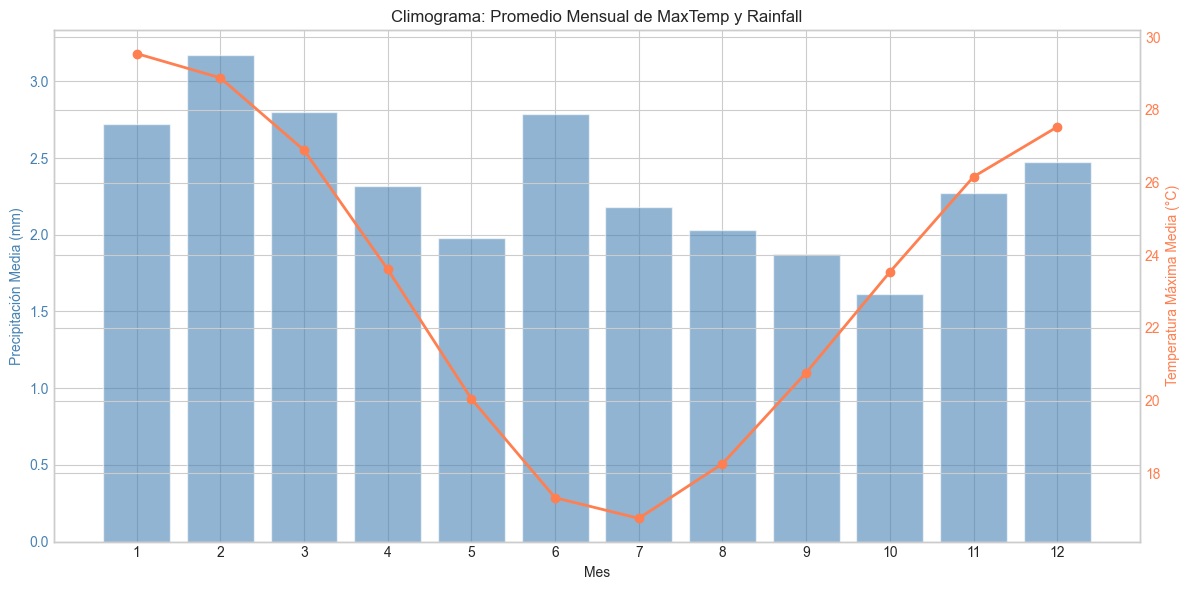

In [60]:
# Se calcula las medias mensuales
monthly_data = df.groupby('Month').agg({'MaxTemp': 'mean', 'Rainfall': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje primario para la Precipitación
color_rain = 'steelblue'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Precipitación Media (mm)', color=color_rain)
ax1.bar(monthly_data['Month'], monthly_data['Rainfall'], color=color_rain, alpha=0.6, label='Rainfall')
ax1.tick_params(axis='y', labelcolor=color_rain)
ax1.set_xticks(range(1, 13))

# Eje secundario para la Temperatura
ax2 = ax1.twinx()
color_temp = 'coral'
ax2.set_ylabel('Temperatura Máxima Media (°C)', color=color_temp)
ax2.plot(monthly_data['Month'], monthly_data['MaxTemp'], color=color_temp, marker='o', linewidth=2, label='MaxTemp')
ax2.tick_params(axis='y', labelcolor=color_temp)

plt.title('Climograma: Promedio Mensual de MaxTemp y Rainfall')
fig.tight_layout()
plt.show()

# Mas util separado por region

In [61]:
# Coordenadas (latitud, longitud) de las 33 ciudades del dataset
coordenadas_ciudades = {
    'Albury':          (-36.0737, 146.9135),
    'BadgerysCreek':   (-33.8830, 150.7717),
    'Cobar':           (-31.4980, 145.8347),
    'CoffsHarbour':    (-30.2963, 153.1135),
    'Moree':           (-29.4640, 149.8344),
    'Newcastle':       (-32.9283, 151.7817),
    'NorahHead':       (-33.2833, 151.5667),
    'NorfolkIsland':   (-29.0408, 167.9547),
    'Penrith':         (-33.7510, 150.6940),
    'Richmond':        (-33.5996, 150.7510),
    'Sydney':          (-33.8688, 151.2093),
    'SydneyAirport':   (-33.9399, 151.1753),
    'WaggaWagga':      (-35.1082, 147.3598),
    'Williamtown':     (-32.8150, 151.8428),
    'Wollongong':      (-34.4278, 150.8931),
    'Canberra':        (-35.2809, 149.1300),
    'Tuggeranong':     (-35.4156, 149.0888),
    'MountGinini':     (-35.5294, 148.7723),
    'Ballarat':        (-37.5622, 143.8503),
    'Bendigo':         (-36.7570, 144.2794),
    'Sale':            (-38.1051, 147.0658),
    'MelbourneAirport':(-37.6733, 144.8433),
    'Melbourne':       (-37.8136, 144.9631),
    'Mildura':         (-34.2080, 142.1246),
    'Nhil':            (-36.3328, 141.6503),
    'Portland':        (-38.3457, 141.6042),
    'Watsonia':        (-37.7110, 145.0830),
    'Dartmoor':        (-37.9220, 141.2760),
    'Brisbane':        (-27.4698, 153.0251),
    'Cairns':          (-16.9186, 145.7781),
    'GoldCoast':       (-28.0167, 153.4000),
    'Townsville':      (-19.2589, 146.8169),
    'Adelaide':        (-34.9285, 138.6007),
}

# Verificamos que están todas las ciudades del dataset
ciudades_dataset = set(df['Location'].unique())
ciudades_dict = set(coordenadas_ciudades.keys())

print(f'Ciudades en dataset: {len(ciudades_dataset)}')
print(f'Ciudades en diccionario: {len(ciudades_dict)}')
print(f'Faltantes en el diccionario: {ciudades_dataset - ciudades_dict}')
print(f'Sobran en el diccionario: {ciudades_dict - ciudades_dataset}')

Ciudades en dataset: 49
Ciudades en diccionario: 33
Faltantes en el diccionario: {'Uluru', 'Katherine', 'Witchcliffe', 'Hobart', 'Nuriootpa', 'Albany', 'Darwin', 'PearceRAAF', 'AliceSprings', 'MountGambier', 'PerthAirport', 'SalmonGums', 'Launceston', 'Walpole', 'Perth', 'Woomera'}
Sobran en el diccionario: set()


In [62]:

ciudades_faltantes = ['PerthAirport', 'SalmonGums', 'Nuriootpa', 'Woomera', 'Albany', 'AliceSprings',
                      'Katherine', 'PearceRAAF', 'Uluru', 'Darwin', 'Launceston',
                      'Hobart', 'Witchcliffe', 'Walpole', 'MountGambier', 'Perth']

print("Cantidad de filas sin Region",len(df[df['Location'].isin(ciudades_faltantes)]))

Cantidad de filas sin Region 45238


In [63]:
coordenadas_ciudades = {
  
    'Albury':           (-36.0737, 146.9135),
    'BadgerysCreek':    (-33.8830, 150.7717),
    'Cobar':            (-31.4980, 145.8347),
    'CoffsHarbour':     (-30.2963, 153.1135),
    'Moree':            (-29.4640, 149.8344),
    'Newcastle':        (-32.9283, 151.7817),
    'NorahHead':        (-33.2833, 151.5667),
    'NorfolkIsland':    (-29.0408, 167.9547),
    'Penrith':          (-33.7510, 150.6940),
    'Richmond':         (-33.5996, 150.7510),
    'Sydney':           (-33.8688, 151.2093),
    'SydneyAirport':    (-33.9399, 151.1753),
    'WaggaWagga':       (-35.1082, 147.3598),
    'Williamtown':      (-32.8150, 151.8428),
    'Wollongong':       (-34.4278, 150.8931),
    'Canberra':         (-35.2809, 149.1300),
    'Tuggeranong':      (-35.4156, 149.0888),
    'MountGinini':      (-35.5294, 148.7723),
    'Ballarat':         (-37.5622, 143.8503),
    'Bendigo':          (-36.7570, 144.2794),
    'Sale':             (-38.1051, 147.0658),
    'MelbourneAirport': (-37.6733, 144.8433),
    'Melbourne':        (-37.8136, 144.9631),
    'Mildura':          (-34.2080, 142.1246),
    'Nhil':             (-36.3328, 141.6503),
    'Portland':         (-38.3457, 141.6042),
    'Watsonia':         (-37.7110, 145.0830),
    'Dartmoor':         (-37.9220, 141.2760),
    'Brisbane':         (-27.4698, 153.0251),
    'Cairns':           (-16.9186, 145.7781),
    'GoldCoast':        (-28.0167, 153.4000),
    'Townsville':       (-19.2589, 146.8169),
    'Adelaide':         (-34.9285, 138.6007),

    # --- Ubicaciones Completadas ---
    'PerthAirport':     (-31.9403, 115.9669),
    'SalmonGums':       (-32.9815, 121.6438),
    'Nuriootpa':        (-34.4667, 138.9833),
    'Woomera':          (-31.1997, 136.8253),
    'Albany':           (-35.0269, 117.8837),
    'AliceSprings':     (-23.6980, 133.8807),
    'Katherine':        (-14.4651, 132.2635),
    'PearceRAAF':       (-31.6676, 116.0292),
    'Uluru':            (-25.3444, 131.0369),
    'Darwin':           (-12.4634, 130.8456),
    'Launceston':       (-41.4332, 147.1441),
    'Hobart':           (-42.8821, 147.3272),
    'Witchcliffe':      (-34.0261, 115.1005),
    'Walpole':          (-34.9777, 116.7338),
    'MountGambier':     (-37.8284, 140.7804),
    'Perth':            (-31.9505, 115.8605)
}

In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

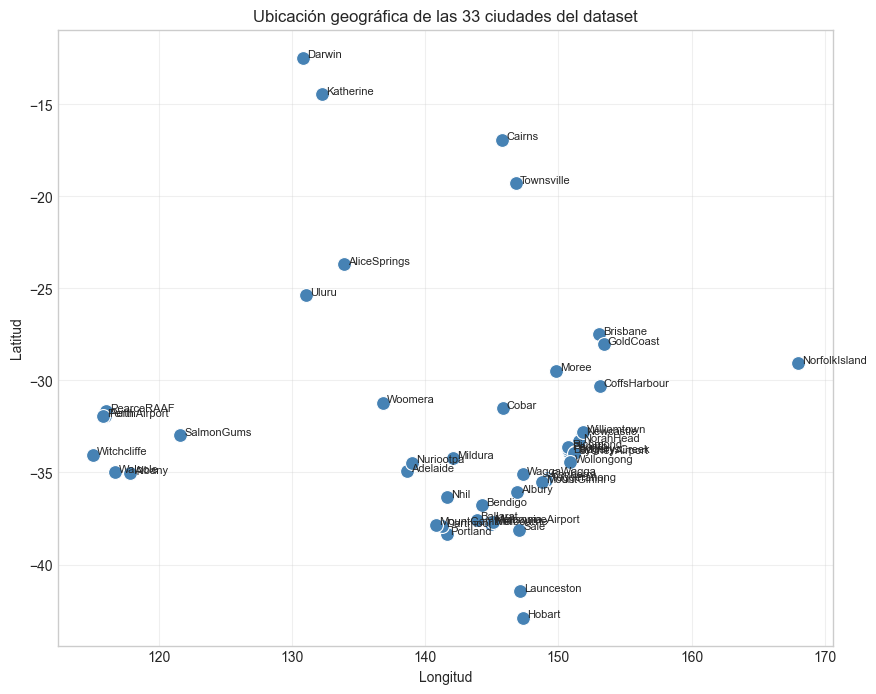

In [65]:
# Armamos un DataFrame auxiliar con las coordenadas
df_coords = pd.DataFrame([
    {'Location': loc, 'Latitude': lat, 'Longitude': lon}
    for loc, (lat, lon) in coordenadas_ciudades.items()
])

# Visualizamos las ciudades en el mapa
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_coords, x='Longitude', y='Latitude', s=100, color='steelblue')

# Etiquetamos cada ciudad
for _, row in df_coords.iterrows():
    plt.text(row['Longitude'] + 0.3, row['Latitude'], row['Location'], fontsize=8)

plt.title('Ubicación geográfica de las 33 ciudades del dataset')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, alpha=0.3)
plt.show()

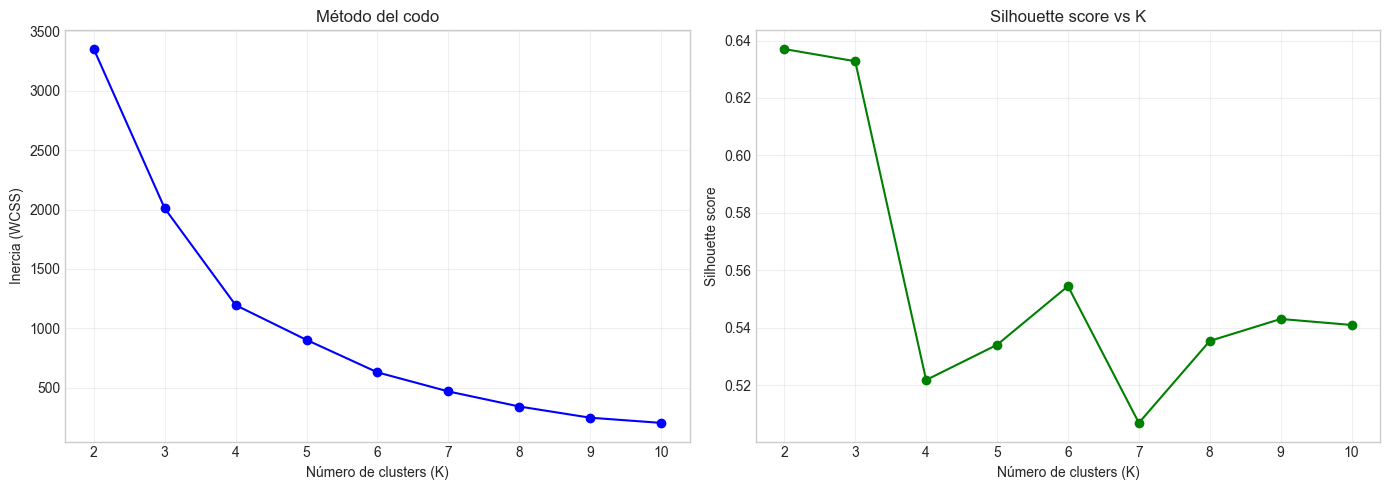


Valores numéricos:
K=2: Inercia=3352.24 | Silhouette=0.6370
K=3: Inercia=2010.56 | Silhouette=0.6328
K=4: Inercia=1195.16 | Silhouette=0.5218
K=5: Inercia= 902.14 | Silhouette=0.5341
K=6: Inercia= 628.74 | Silhouette=0.5545
K=7: Inercia= 468.06 | Silhouette=0.5069
K=8: Inercia= 341.04 | Silhouette=0.5354
K=9: Inercia= 246.70 | Silhouette=0.5431
K=10: Inercia= 203.05 | Silhouette=0.5410


In [66]:
# Matriz de coordenadas (las 33 ciudades únicas)
X_coords = df_coords[['Latitude', 'Longitude']].values

# Probamos K de 2 a 10
K_range = range(2, 11)
inercias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_coords)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_coords, labels))

# Graficamos ambas métricas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inercias, 'bo-')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del codo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'go-')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score vs K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimimos los valores
print('\nValores numéricos:')
for k, inertia, sil in zip(K_range, inercias, silhouettes):
    print(f'K={k}: Inercia={inertia:7.2f} | Silhouette={sil:.4f}')

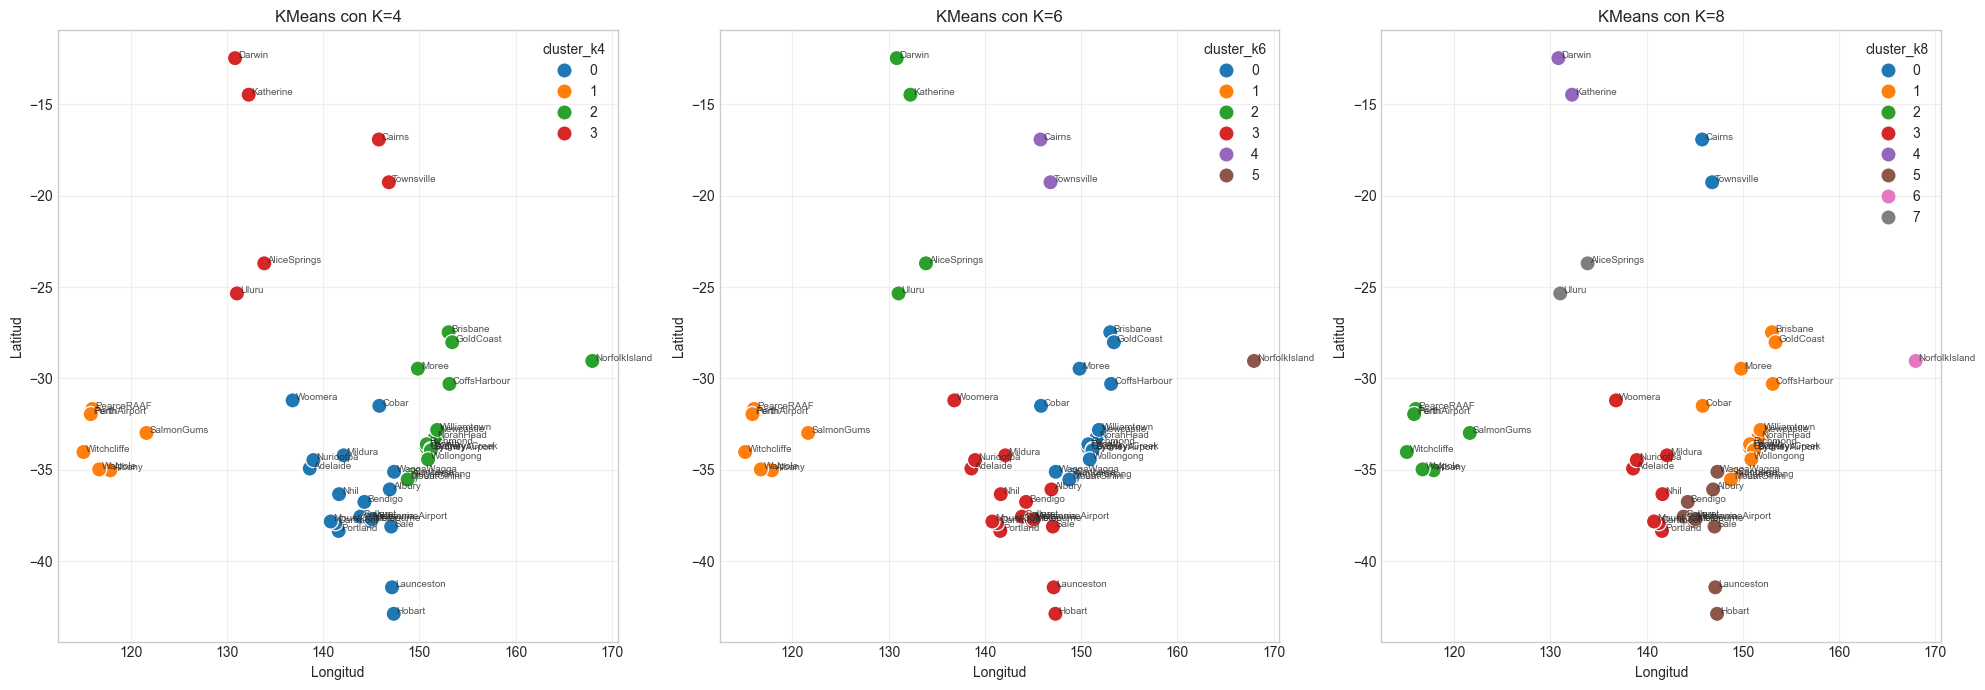

In [67]:
# Probamos visualmente K=4, K=6 y K=8 para confirmar la elección
K_a_probar = [4, 6, 8]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, k in zip(axes, K_a_probar):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_coords[f'cluster_k{k}'] = kmeans.fit_predict(X_coords)

    sns.scatterplot(
        data=df_coords,
        x='Longitude', y='Latitude',
        hue=f'cluster_k{k}',
        palette='tab10',
        s=120,
        ax=ax,
        legend='full'
    )

    # Etiquetas de ciudades
    for _, row in df_coords.iterrows():
        ax.text(row['Longitude'] + 0.3, row['Latitude'], row['Location'],
                fontsize=7, alpha=0.8)

    ax.set_title(f'KMeans con K={k}')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

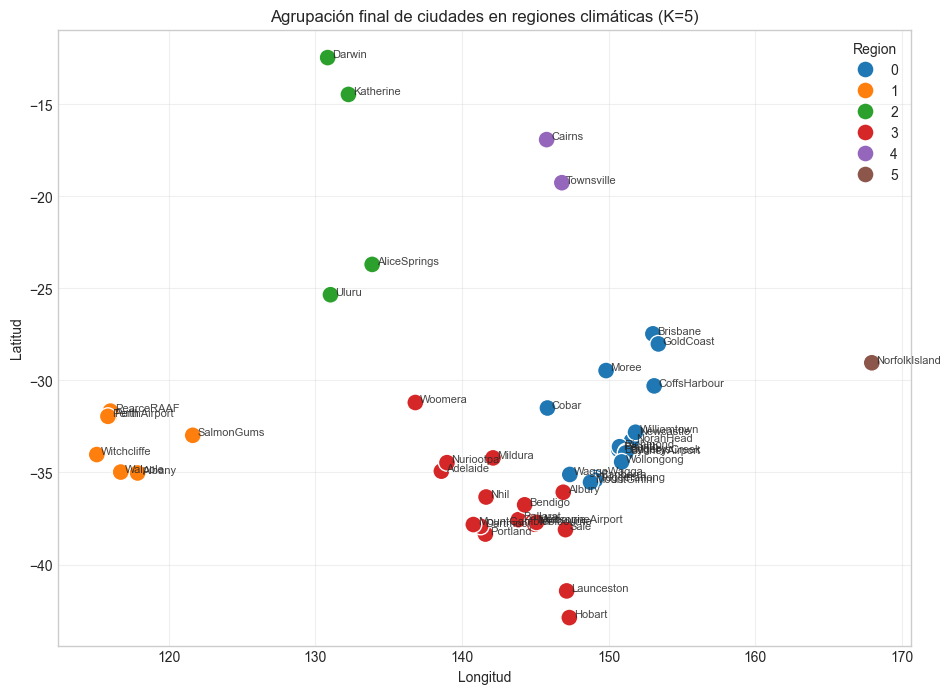


Ciudades por región:

Región 0 (18 ciudades): ['BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree', 'Newcastle', 'NorahHead', 'Penrith', 'Richmond', 'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown', 'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Brisbane', 'GoldCoast']

Región 1 (7 ciudades): ['PerthAirport', 'SalmonGums', 'Albany', 'PearceRAAF', 'Witchcliffe', 'Walpole', 'Perth']

Región 2 (4 ciudades): ['AliceSprings', 'Katherine', 'Uluru', 'Darwin']

Región 3 (17 ciudades): ['Albury', 'Ballarat', 'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura', 'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Adelaide', 'Nuriootpa', 'Woomera', 'Launceston', 'Hobart', 'MountGambier']

Región 4 (2 ciudades): ['Cairns', 'Townsville']

Región 5 (1 ciudades): ['NorfolkIsland']


In [68]:
# Entrenamos KMeans con K=6
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df_coords['Region'] = kmeans_final.fit_predict(X_coords)

# Visualizamos el resultado final
plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=df_coords,
    x='Longitude', y='Latitude',
    hue='Region',
    palette='tab10',
    s=150,
    legend='full'
)

for _, row in df_coords.iterrows():
    plt.text(row['Longitude'] + 0.3, row['Latitude'], row['Location'],
             fontsize=8, alpha=0.85)

plt.title('Agrupación final de ciudades en regiones climáticas (K=5)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, alpha=0.3)
plt.show()

# Mostramos qué ciudades quedaron en cada región
print('\nCiudades por región:')
for region in sorted(df_coords['Region'].unique()):
    ciudades_region = df_coords[df_coords['Region'] == region]['Location'].tolist()
    print(f'\nRegión {region} ({len(ciudades_region)} ciudades): {ciudades_region}')

In [69]:
# Limpiamos columnas auxiliares de las pruebas anteriores
columnas_auxiliares = [col for col in df_coords.columns if col.startswith('cluster_k')]
df_coords = df_coords.drop(columns=columnas_auxiliares)
df_coords.head()

,Location,Latitude,Longitude,Region
0,Albury,-36.0737,146.9135,3
1,BadgerysCreek,-33.8830,150.7717,0
2,Cobar,-31.4980,145.8347,0
3,CoffsHarbour,-30.2963,153.1135,0
4,Moree,-29.4640,149.8344,0


In [70]:
# Mergeamos la región al df principal y eliminamos Location
df = df.merge(df_coords[['Location', 'Region']], on='Location', how='left')
#df = df.drop(columns=['Location'])

# Verificamos
print(f'Columnas: {df.shape[1]}')
print(f'\nDistribución de observaciones por región:')
print(df['Region'].value_counts().sort_index())
print(f'\nNulos en Region: {df["Region"].isna().sum()}')
df.head()

Columnas: 30

Distribución de observaciones por región:
Region
0    53823
1    20699
2     9303
3    49346
4     6019
5     2963
Name: count, dtype: int64

Nulos en Region: 0


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,DayOfYear,Month,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,Region
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,0,0,336,12,-0.478734,0.877960,-2.449294e-16,1.0,3
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,23.0,40.1,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,0,0,337,12,-0.463550,0.886071,-2.449294e-16,1.0,3
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,WSW,20.0,27.0,36.2,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,0,0,338,12,-0.448229,0.893919,-2.449294e-16,1.0,3
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,E,10.0,10.0,45.8,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,0,0,339,12,-0.432776,0.901502,-2.449294e-16,1.0,3
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,NW,6.0,17.0,83.5,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,0,0,340,12,-0.417194,0.908818,-2.449294e-16,1.0,3


Agrupación de las estaciones meteorológicas según los criterios científicos oficiales de la [Oficina de Meteorología de Australia (BOM)](https://www.bom.gov.au/resources/learn-and-explore/climate-knowledge-centre/australian-climate-zones)

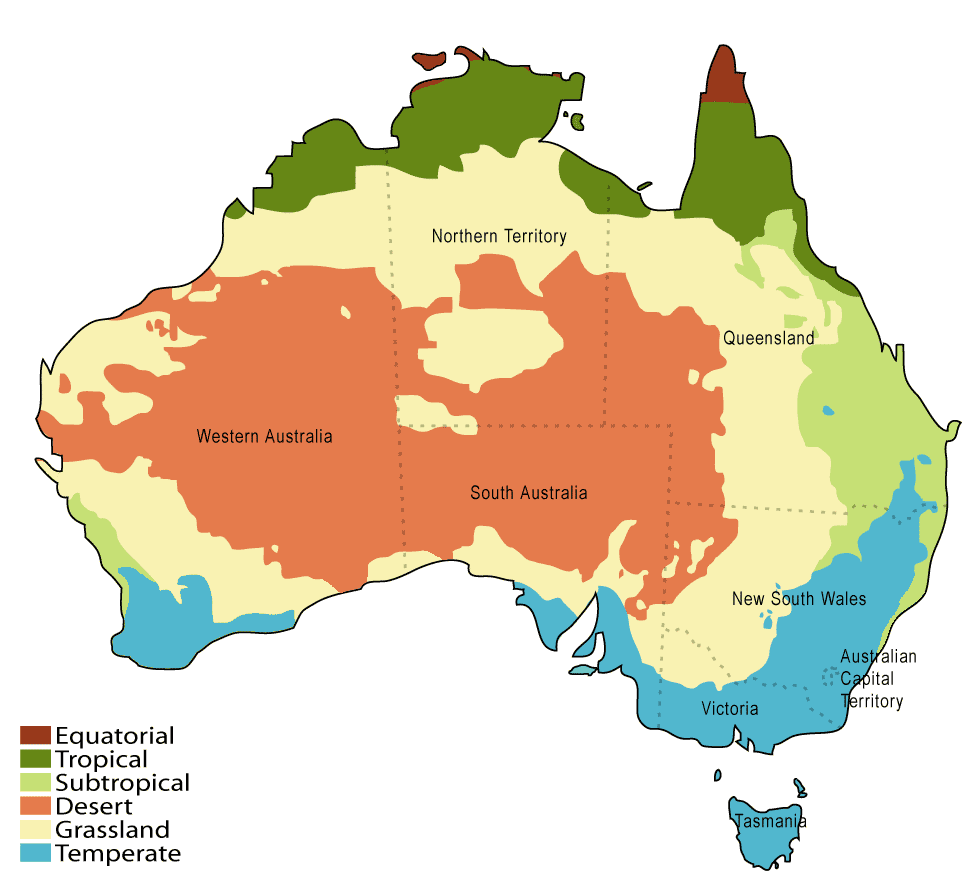

Se agrupan las 49 localidades originales en 7 macro-regiones climáticas basadas en los criterios del BOM, se reduce drásticamente la cardinalidad de la variable espacial.

In [71]:
regiones_climaticas = {
    'Tropical': {
        # Región caracterizada por altas temperaturas todo el año, lluvias intensas en verano y ciclones.
        'Cairns':           (-16.9186, 145.7781),
        'Darwin':           (-12.4634, 130.8456),
        'Katherine':        (-14.4651, 132.2635),
        'Townsville':       (-19.2589, 146.8169)
    },

    'Subtropical': { # (Costa Este)
        # Humedad elevada, veranos cálidos con precipitaciones y estabilidad térmica invernal.
        'Brisbane':         (-27.4698, 153.0251),
        'CoffsHarbour':     (-30.2963, 153.1135),
        'GoldCoast':        (-28.0167, 153.4000),
        'NorfolkIsland':    (-29.0408, 167.9547)  # Territorio marítimo subtropical
    },

    'Desértica': { # (Centro)
        # Precipitaciones ínfimas (<250mm anuales), amplitudes térmicas extremas día/noche.
        'AliceSprings':     (-23.6980, 133.8807),
        'Uluru':            (-25.3444, 131.0369),
        'Woomera':          (-31.1997, 136.8253)
    },

    'Pastizales': { # (Estepa de Transición)
        # Clima seco que rodea los desiertos; alta variabilidad y propenso a sequías estacionales.
        'Cobar':            (-31.4980, 145.8347),
        'Mildura':          (-34.2080, 142.1246),
        'Moree':            (-29.4640, 149.8344),
        'Nhil':             (-36.3328, 141.6503),
        'SalmonGums':       (-32.9815, 121.6438)
    },

    'Templada': { # (Costa Sur y Sureste)
        # Cuatro estaciones bien marcadas. Veranos templados/cálidos e inviernos frescos. Concentra la mayoría de las estaciones.
        'Adelaide':         (-34.9285, 138.6007),
        'Albury':           (-36.0737, 146.9135),
        'BadgerysCreek':    (-33.8830, 150.7717),
        'Ballarat':         (-37.5622, 143.8503),
        'Bendigo':          (-36.7570, 144.2794),
        'Canberra':         (-35.2809, 149.1300),
        'Dartmoor':         (-37.9220, 141.2760),
        'Hobart':           (-42.8821, 147.3272),
        'Launceston':       (-41.4332, 147.1441),
        'Melbourne':        (-37.8136, 144.9631),
        'MelbourneAirport': (-37.6733, 144.8433),
        'Newcastle':        (-32.9283, 151.7817),
        'NorahHead':        (-33.2833, 151.5667),
        'Nuriootpa':        (-34.4667, 138.9833),
        'Penrith':          (-33.7510, 150.6940),
        'Richmond':         (-33.5996, 150.7510),
        'Sale':             (-38.1051, 147.0658),
        'Sydney':           (-33.8688, 151.2093),
        'SydneyAirport':    (-33.9399, 151.1753),
        'Tuggeranong':      (-35.4156, 149.0888),
        'WaggaWagga':       (-35.1082, 147.3598),
        'Watsonia':         (-37.7110, 145.0830),
        'Williamtown':      (-32.8150, 151.8428),
        'Wollongong':       (-34.4278, 150.8931)
    },

    'Oceánica': { # (Sudoeste y Costa Sur Fría)
        # Inviernos muy lluviosos por frentes antárticos y veranos secos (típico del sudoeste de WA y franja sur costera).
        'Albany':           (-35.0269, 117.8837),
        'MountGambier':     (-37.8284, 140.7804),
        'PearceRAAF':       (-31.6676, 116.0292),
        'Perth':            (-31.9505, 115.8605),
        'PerthAirport':     (-31.9403, 115.9669),
        'Portland':         (-38.3457, 141.6042),
        'Walpole':          (-34.9777, 116.7338),
        'Witchcliffe':      (-34.0261, 115.1005)
    },

    'Montañoso': {
        # Microclima específico de alta montaña, temperaturas invernales bajo cero y precipitaciones en forma de nieve.
        'MountGinini':      (-35.5294, 148.7723)
    }
}

# Ciudad -> Región Climática.
mapeo_ciudad_region = {
    ciudad: region
    for region, ciudades in regiones_climaticas.items()
    for ciudad in ciudades
}

df['Region_BOM'] = df['Location'].map(mapeo_ciudad_region)

print(f'Distribución de observaciones por región BOM:')
print(df['Region_BOM'].value_counts())
print(f'\nNulos en Region: {df["Region"].isna().sum()}')
df.head()

Distribución de observaciones por región BOM:
Region_BOM
Templada       71743
Oceánica       23770
Pastizales     13368
Subtropical    12054
Tropical       10770
Desértica       7542
Montañoso       2906
Name: count, dtype: int64

Nulos en Region: 0


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,DayOfYear,Month,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,Region,Region_BOM
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,0,0,336,12,-0.478734,0.877960,-2.449294e-16,1.0,3,Templada
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,23.0,40.1,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,0,0,337,12,-0.463550,0.886071,-2.449294e-16,1.0,3,Templada
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,WSW,20.0,27.0,36.2,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,0,0,338,12,-0.448229,0.893919,-2.449294e-16,1.0,3,Templada
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,E,10.0,10.0,45.8,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,0,0,339,12,-0.432776,0.901502,-2.449294e-16,1.0,3,Templada
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,NW,6.0,17.0,83.5,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,0,0,340,12,-0.417194,0.908818,-2.449294e-16,1.0,3,Templada


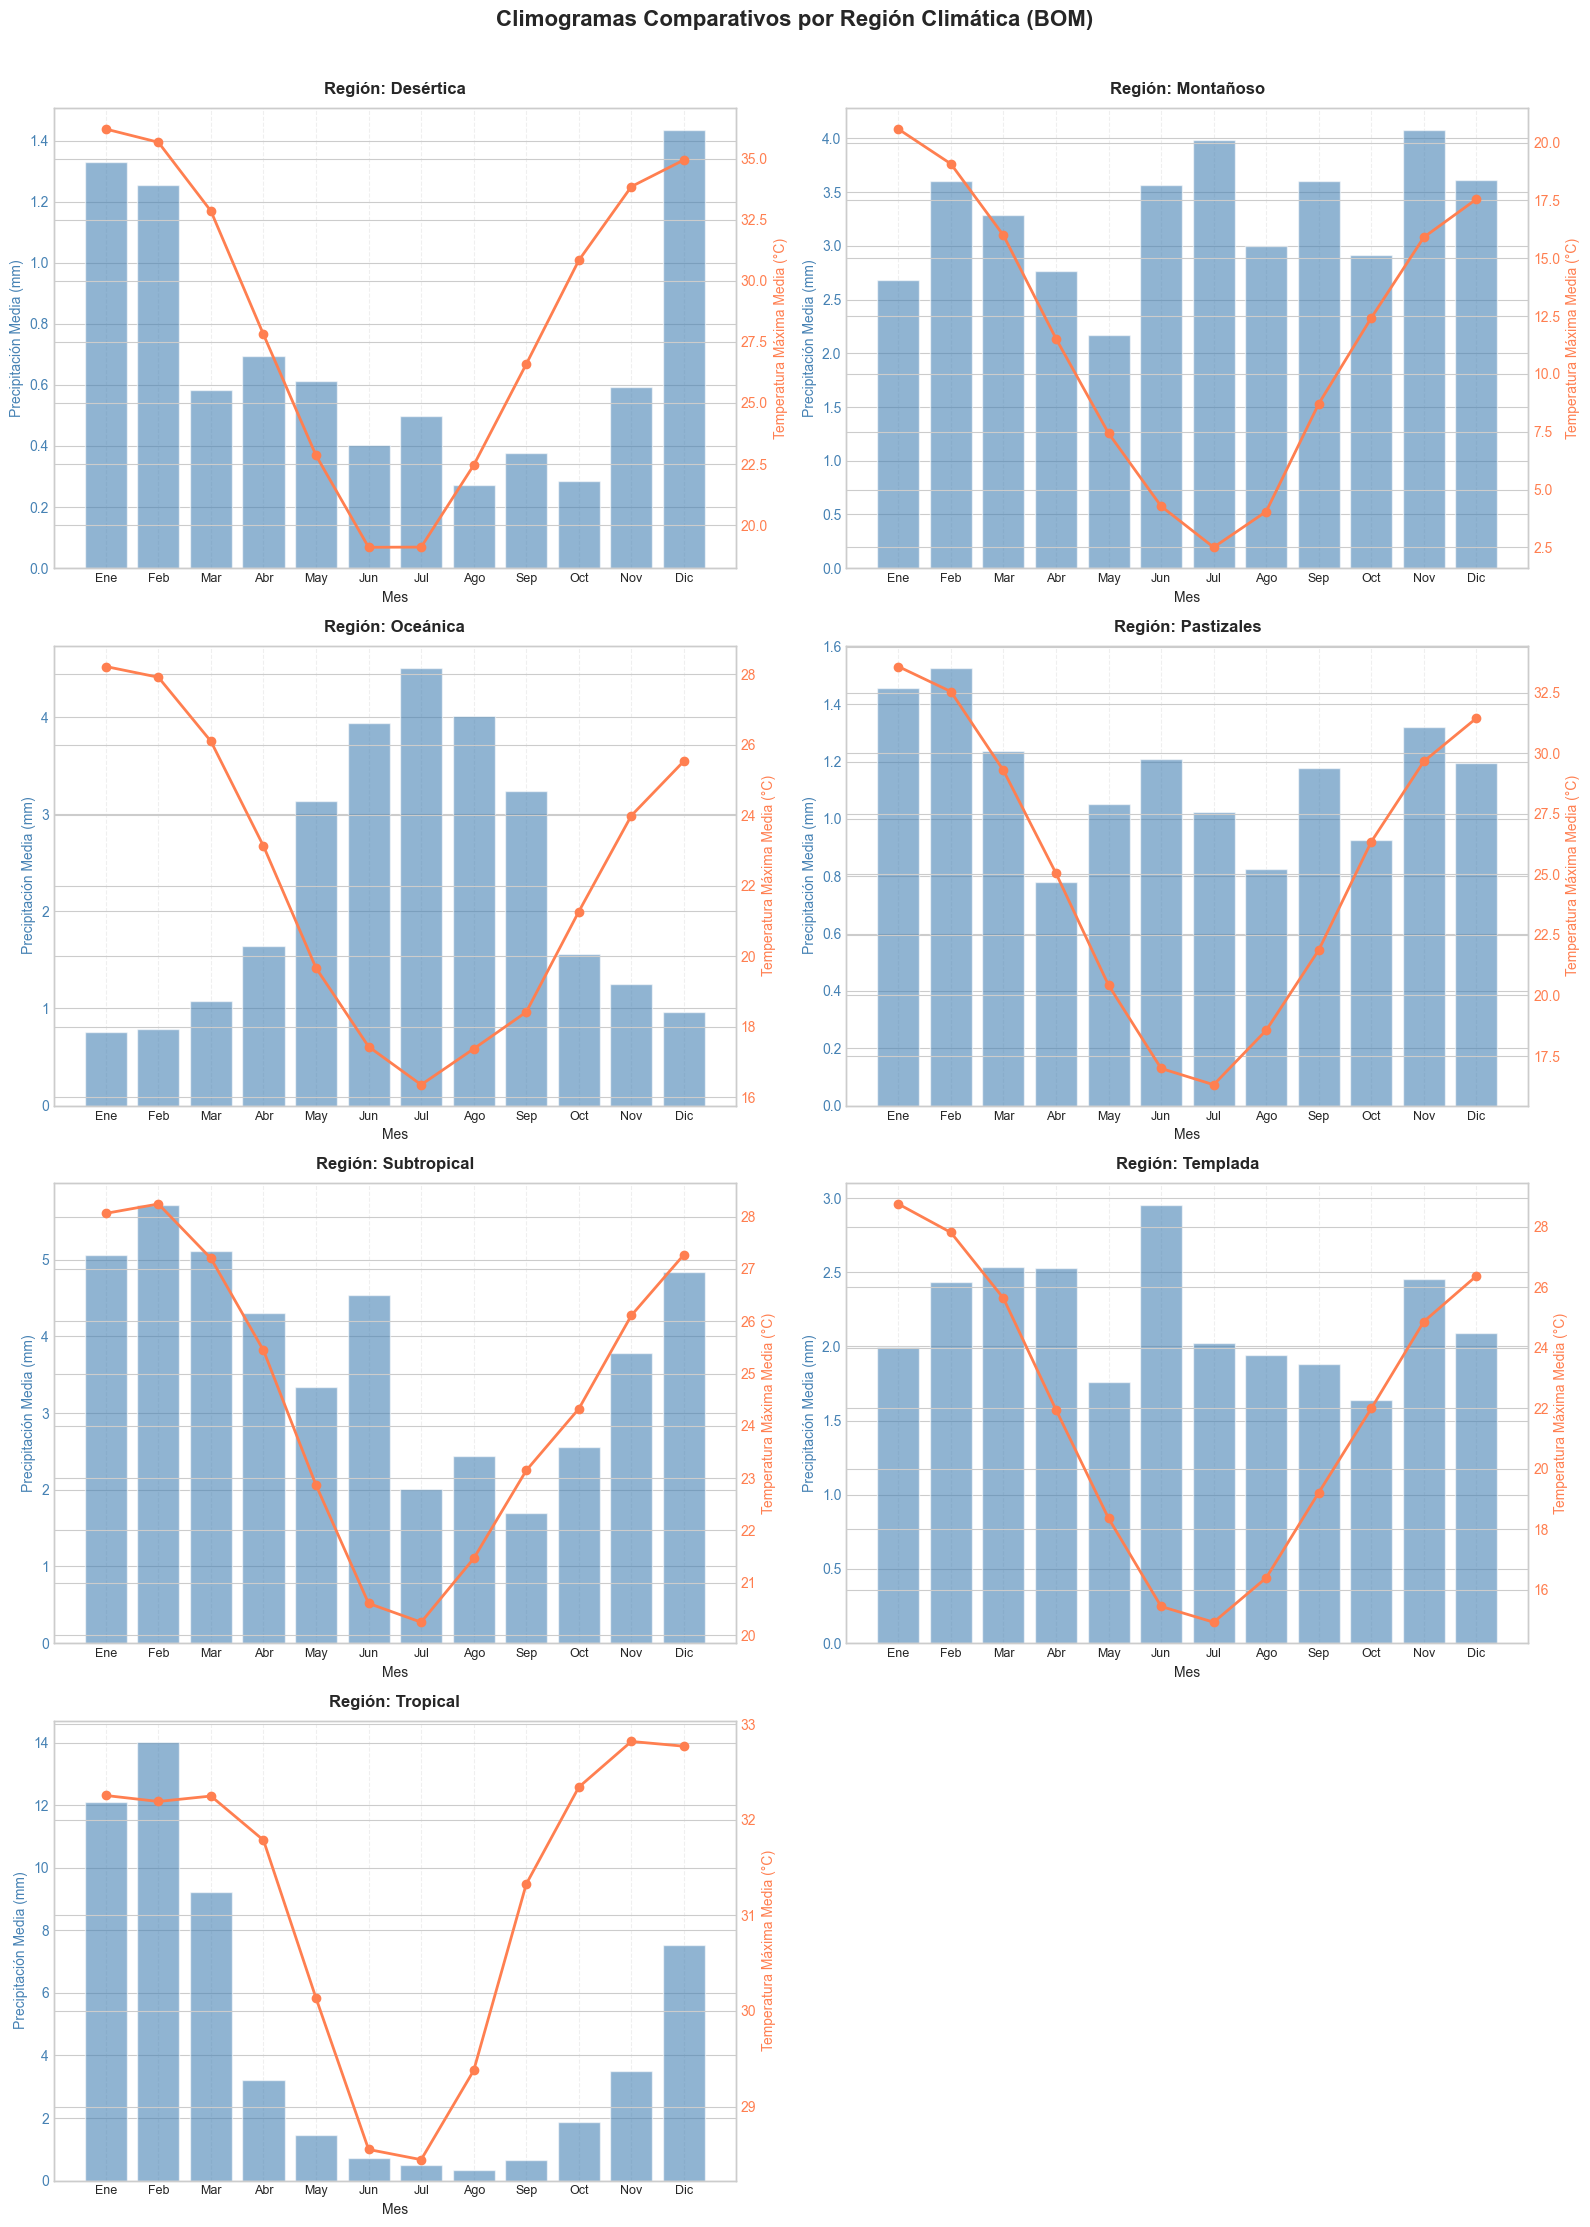

In [72]:

# Se agrupa los datos simultáneamente por Región y por Mes para calcular las medias correspondientes
monthly_data = df.groupby(['Region_BOM', 'Month']).agg({'MaxTemp': 'mean', 'Rainfall': 'mean'}).reset_index()

regiones = monthly_data['Region_BOM'].dropna().unique()
num_regiones = len(regiones)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22), sharex=False)
axes = axes.flatten()

color_rain = 'steelblue'
color_temp = 'coral'

# Construcción del climograma para cada región climática
for i, region in enumerate(regiones):
    ax1 = axes[i]

    data_region = monthly_data[monthly_data['Region_BOM'] == region].sort_values('Month')

    # --- Eje Primario (Izquierdo): Precipitación ---
    ax1.bar(data_region['Month'], data_region['Rainfall'], color=color_rain, alpha=0.6, label='Precipitación')
    ax1.set_ylabel('Precipitación Media (mm)', color=color_rain, fontsize=10)
    ax1.tick_params(axis='y', labelcolor=color_rain)
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], fontsize=9)
    ax1.set_xlabel('Mes', fontsize=10)

    # --- Eje Secundario (Derecho): Temperatura Máxima ---
    ax2 = ax1.twinx()
    ax2.plot(data_region['Month'], data_region['MaxTemp'], color=color_temp, marker='o', linewidth=2, label='Temp Máx')
    ax2.set_ylabel('Temperatura Máxima Media (°C)', color=color_temp, fontsize=10)
    ax2.tick_params(axis='y', labelcolor=color_temp)

    # Personalización estética de cada panel
    ax1.set_title(f'Región: {region}', fontsize=12, fontweight='bold', pad=10)
    ax1.grid(True, linestyle='--', alpha=0.3, axis='x')

for j in range(num_regiones, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Climogramas Comparativos por Región Climática (BOM)', fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout()

Mientras la región Ecuatorial / Tropical experimenta un pico masivo de precipitaciones de diciembre a marzo y temperaturas altas estables, las regiones Oceánica y Templada exhiben un comportamiento totalmente inverso: inviernos más fríos (junio a agosto) acompañados por un incremento en la frecuencia de lluvias.

In [73]:
df.head(1)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,DayOfYear,Month,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,Region,Region_BOM
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,0,0,336,12,-0.478734,0.87796,-2.449294e-16,1.0,3,Templada


ANALISIS DE DATOS FALTANTES

In [74]:
# Tabla con cantidad y porcentaje de nulos por columna
nulos = pd.DataFrame({
    'Cantidad': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos['Cantidad'] > 0].sort_values('Porcentaje', ascending=False)
nulos

,Cantidad,Porcentaje
Sunshine,67785,47.68
Evaporation,60812,42.78
Cloud3pm,57076,40.15
Cloud9am,53641,37.73
Pressure9am,14010,9.86
Pressure3pm,13977,9.83
WindDir9am,10009,7.04
WindGustDir,9328,6.56
WindGustSpeed,9268,6.52
WindDir3pm,3776,2.66


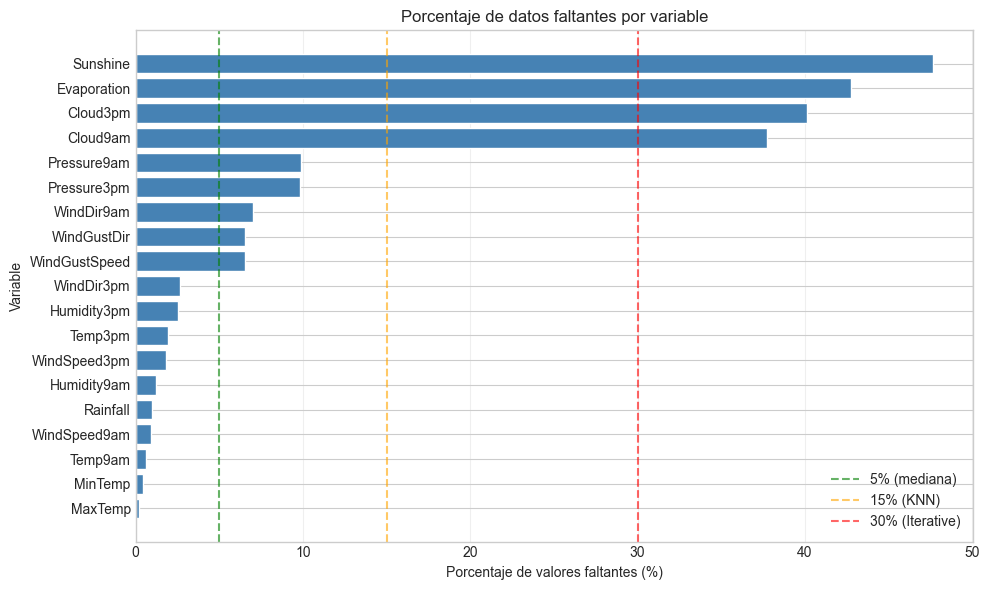

In [75]:
# Visualización de faltantes
plt.figure(figsize=(10, 6))
plt.barh(nulos.index, nulos['Porcentaje'], color='steelblue')
plt.xlabel('Porcentaje de valores faltantes (%)')
plt.ylabel('Variable')
plt.title('Porcentaje de datos faltantes por variable')
plt.gca().invert_yaxis()  # mayor arriba
plt.grid(True, alpha=0.3, axis='x')

# Líneas de referencia para los umbrales de imputación
plt.axvline(x=5, color='green', linestyle='--', alpha=0.6, label='5% (mediana)')
plt.axvline(x=15, color='orange', linestyle='--', alpha=0.6, label='15% (KNN)')
plt.axvline(x=30, color='red', linestyle='--', alpha=0.6, label='30% (Iterative)')
plt.legend()
plt.tight_layout()
plt.show()

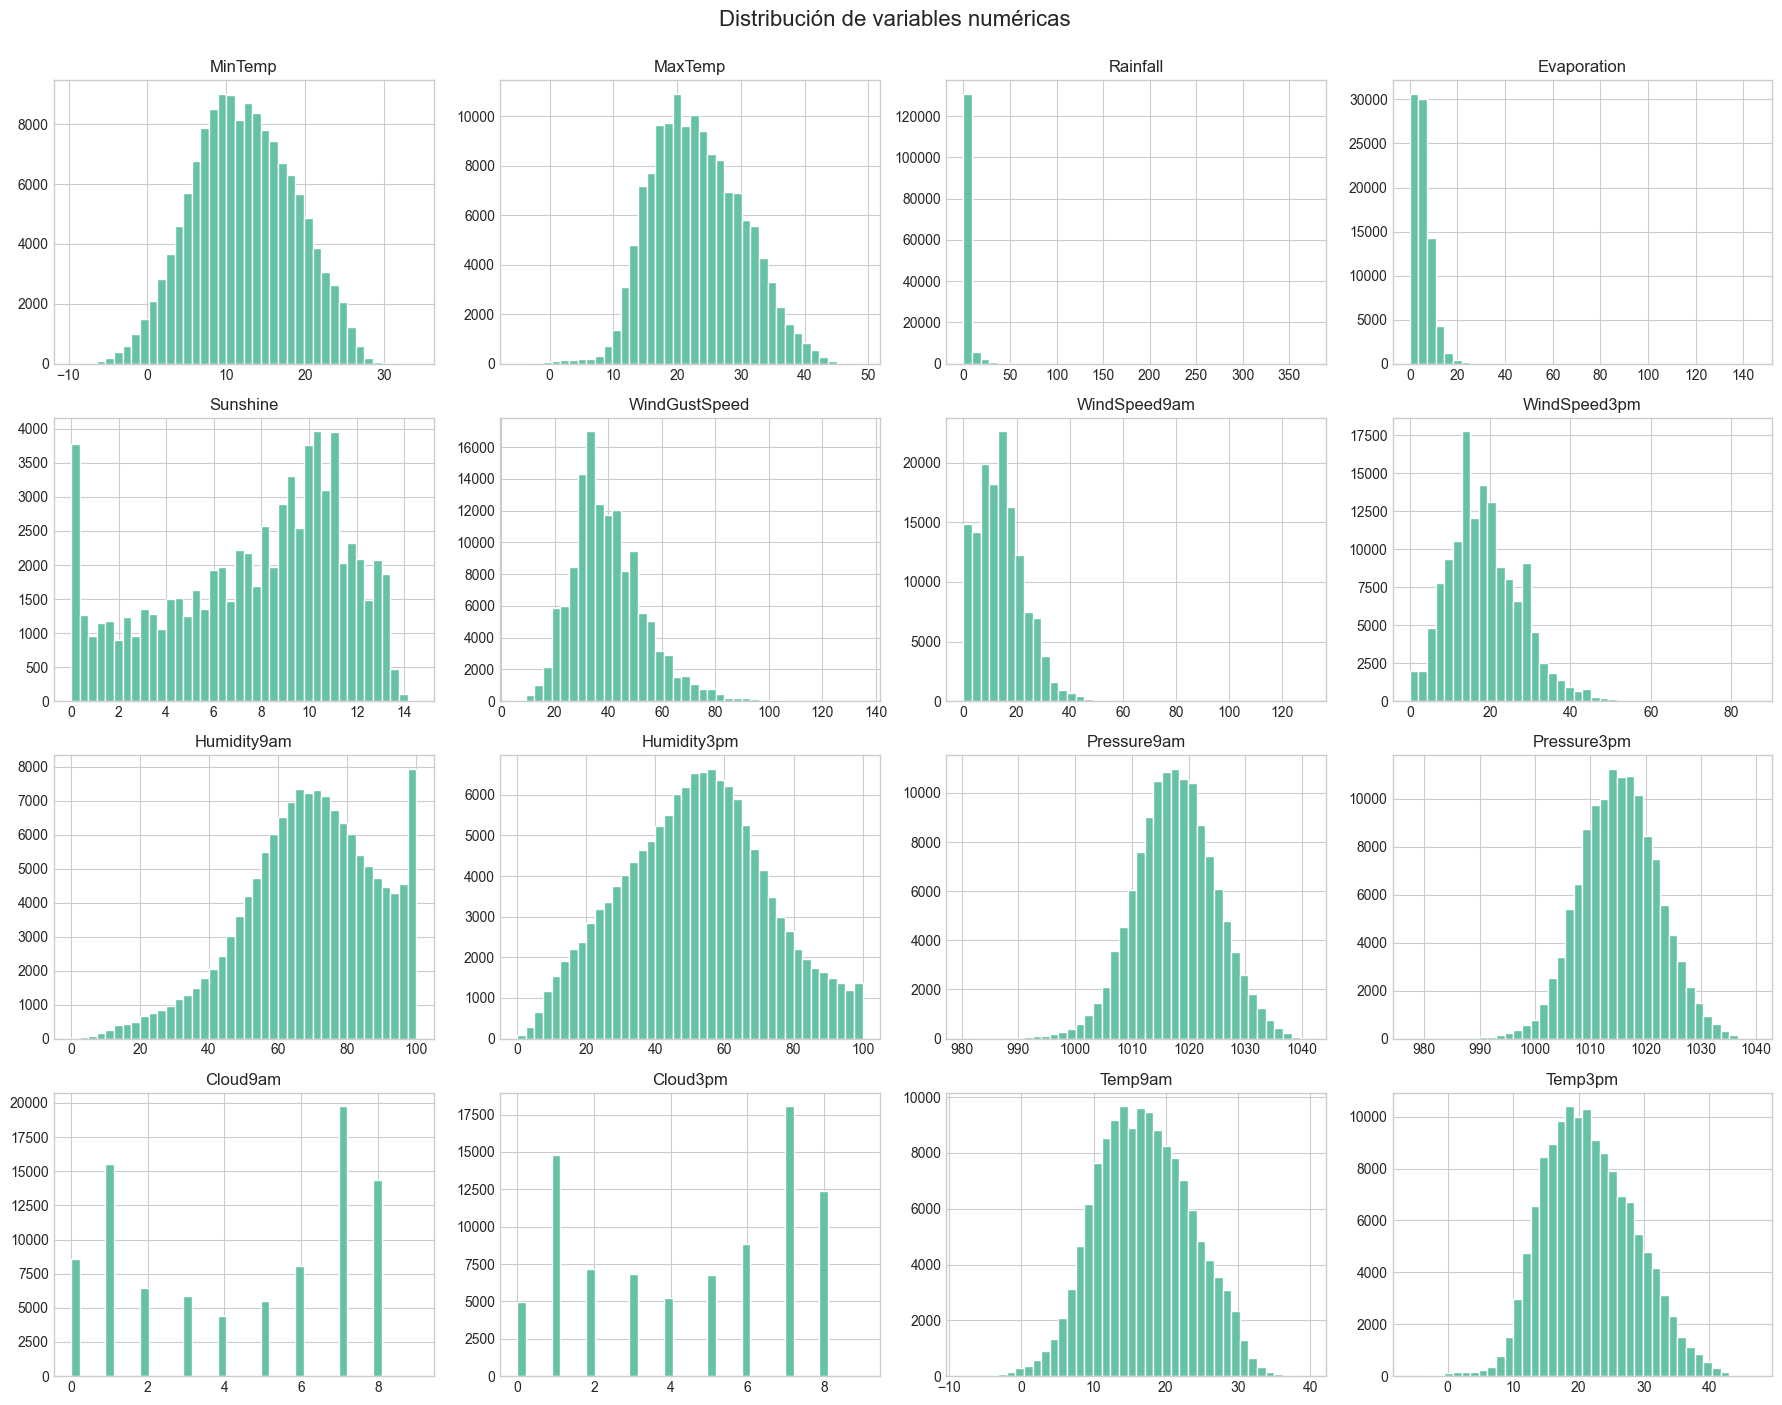

In [76]:
# Seleccionamos solo variables numéricas 
columnas_numericas = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                      'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                      'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                      'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

# Histogramas
df[columnas_numericas].hist(figsize=(18, 14), bins=40, edgecolor='white')
plt.suptitle('Distribución de variables numéricas', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [77]:
print('Valores únicos en Cloud9am:', sorted(df['Cloud9am'].dropna().unique()))
print('Valores únicos en Cloud3pm:', sorted(df['Cloud3pm'].dropna().unique()))

Valores únicos en Cloud9am: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
Valores únicos en Cloud3pm: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]


In [78]:
# Cuántas observaciones tienen Cloud9am = 9
cant_9 = (df['Cloud9am'] == 9).sum()
total = df['Cloud9am'].notna().sum()
print(f'Cloud9am = 9: {cant_9} casos ({cant_9/total*100:.2f}% de los no-nulos)')

# Ver cómo se distribuye RainTomorrow cuando Cloud9am = 9
print('\nDistribución de RainTomorrow cuando Cloud9am = 9:')
print(df[df['Cloud9am'] == 9]['RainTomorrow'].value_counts(normalize=True))
print('\nDistribución de RainTomorrow cuando Cloud9am = 8:')
print(df[df['Cloud9am'] == 8]['RainTomorrow'].value_counts(normalize=True))

Cloud9am = 9: 2 casos (0.00% de los no-nulos)

Distribución de RainTomorrow cuando Cloud9am = 9:
RainTomorrow
0    1.0
Name: proportion, dtype: float64

Distribución de RainTomorrow cuando Cloud9am = 8:
RainTomorrow
0    0.544981
1    0.455019
Name: proportion, dtype: float64


In [79]:
# Reemplazamos Cloud9am = 9 por 8 (escala oficial de octas es 0-8)
df.loc[df['Cloud9am'] == 9, 'Cloud9am'] = 8

# Verificación
print('Valores únicos en Cloud9am después de la corrección:',
      sorted(df['Cloud9am'].dropna().unique()))

Valores únicos en Cloud9am después de la corrección: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


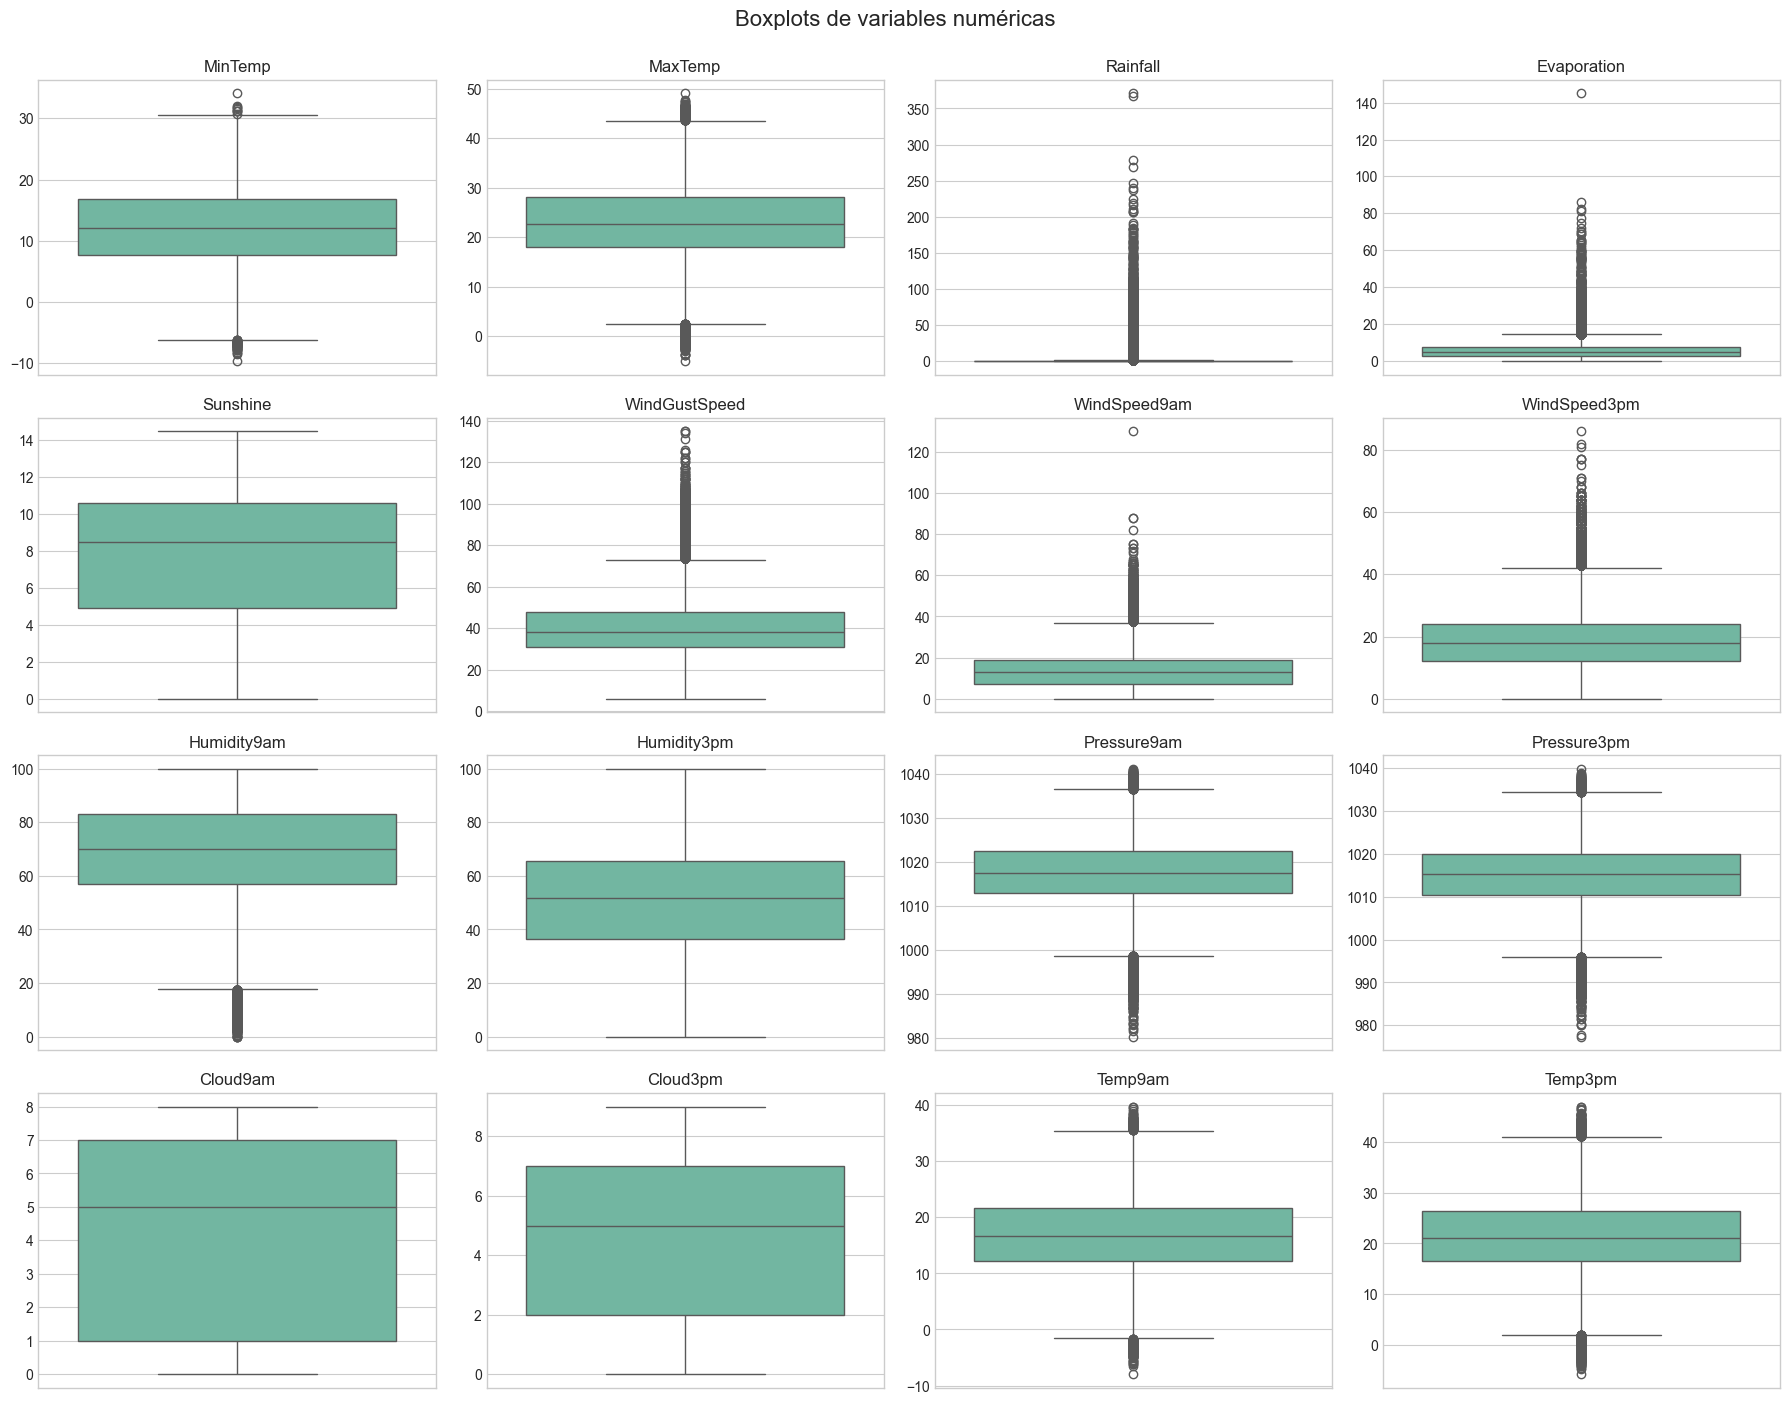

In [80]:
# Boxplots de todas las variables numéricas
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.suptitle('Boxplots de variables numéricas', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

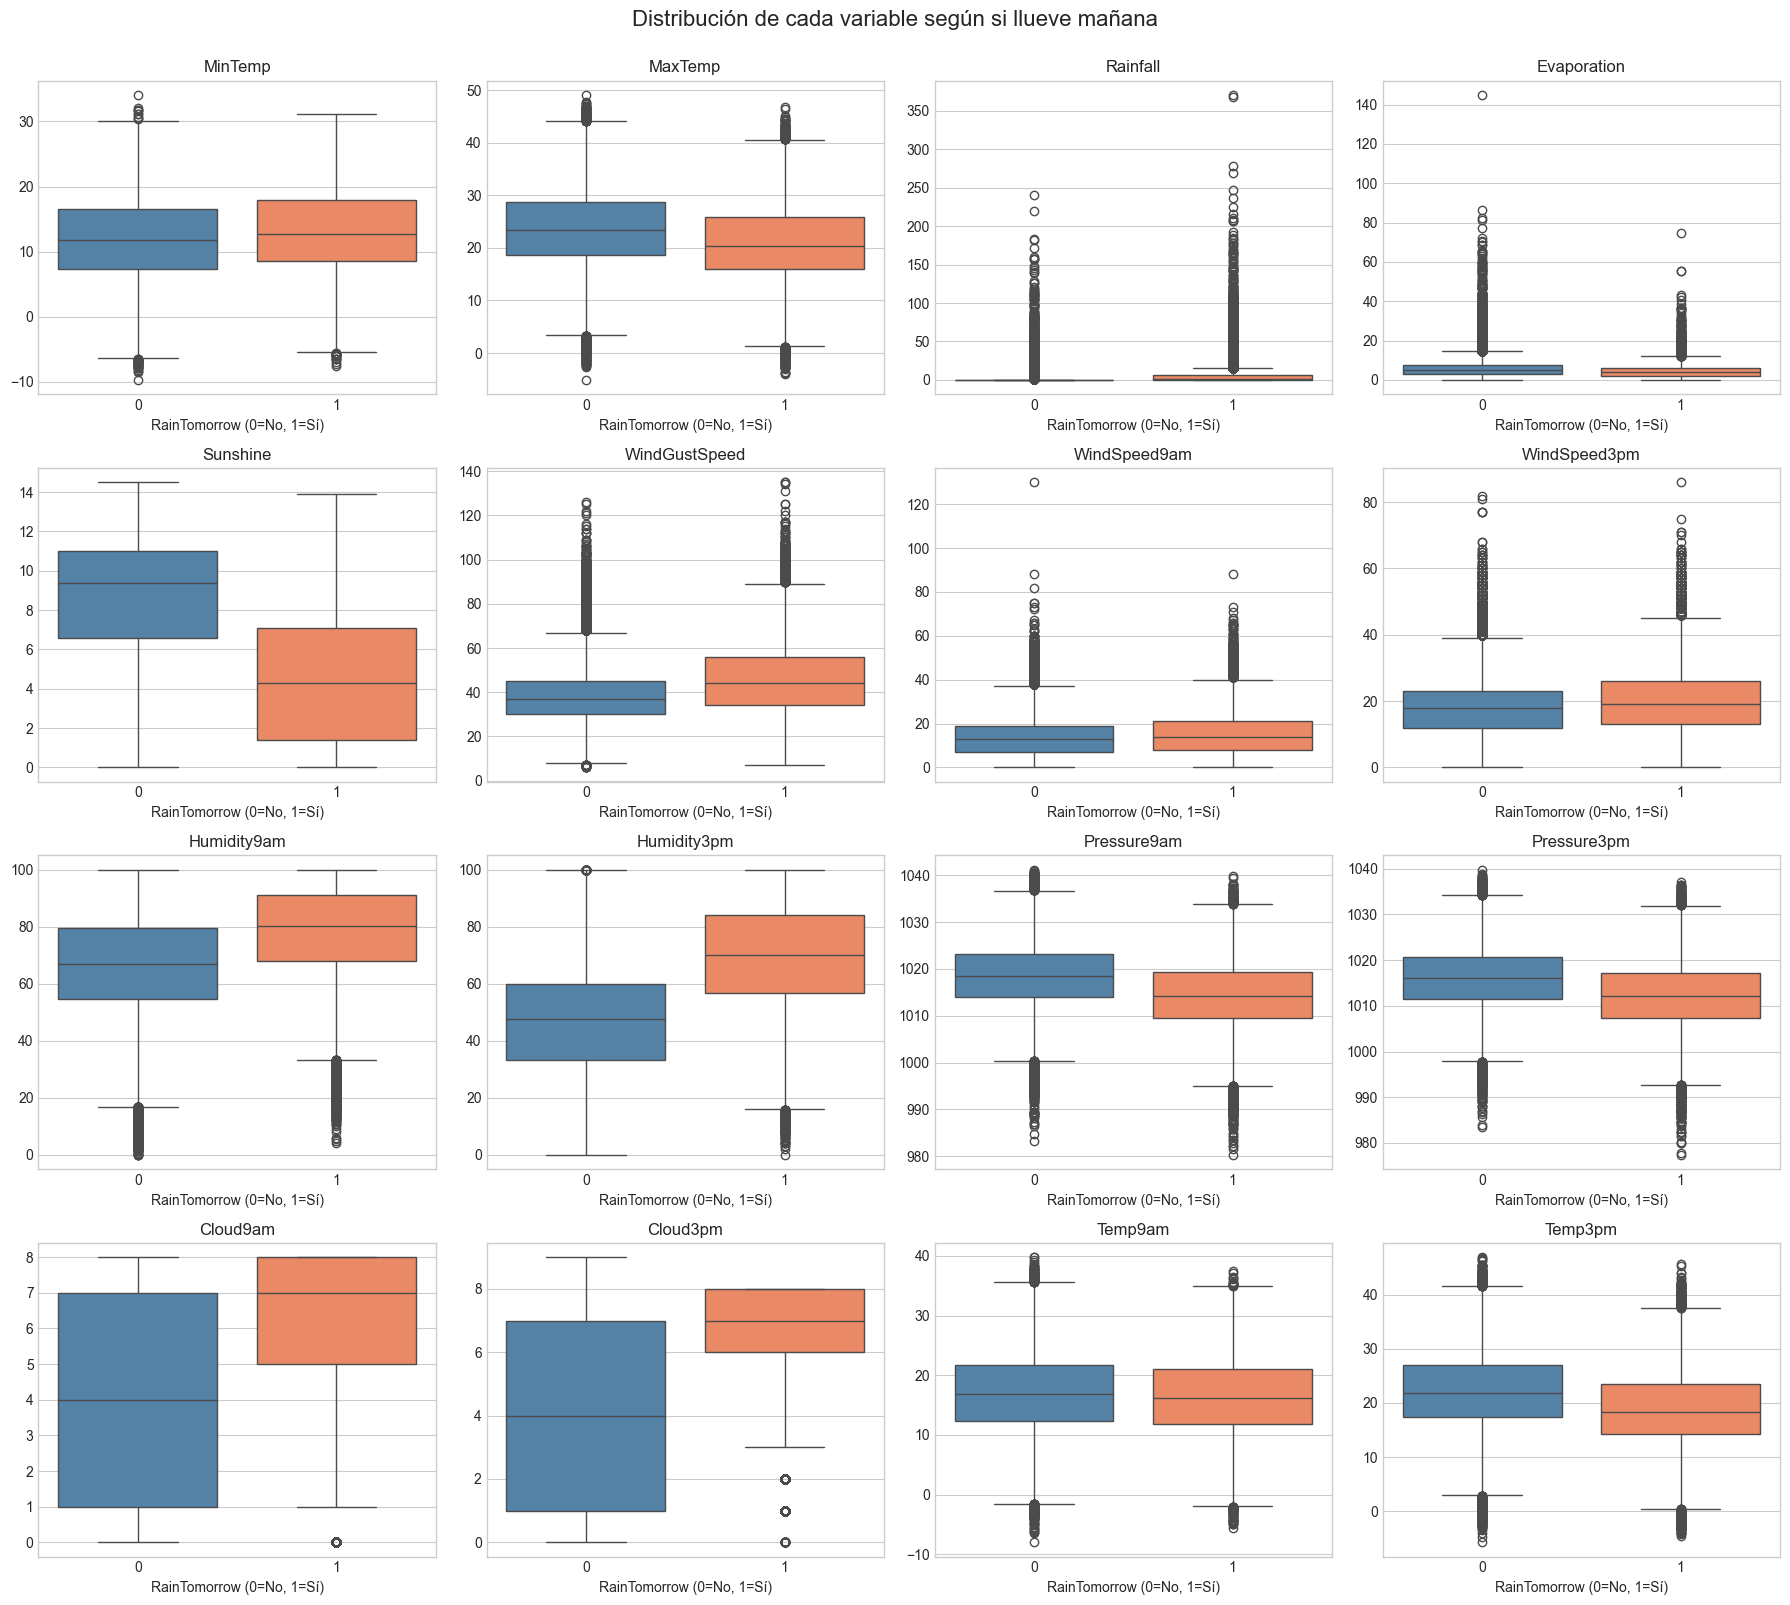

In [81]:
# Boxplots de cada variable numérica segmentados por RainTomorrow
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(
        data=df,
        x='RainTomorrow',
        y=col,
        ax=axes[i],
        hue='RainTomorrow',
        palette={0: 'steelblue', 1: 'coral'},
        legend=False
    )
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('RainTomorrow (0=No, 1=Sí)')
    axes[i].set_ylabel('')

plt.suptitle('Distribución de cada variable según si llueve mañana',
             fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [82]:
# Distribución de la variable objetivo
counts = df['RainTomorrow'].value_counts()
porcentajes = df['RainTomorrow'].value_counts(normalize=True) * 100

print('Cantidad de observaciones por clase:')
print(counts)
print('\nProporción por clase:')
print(porcentajes.round(2))

Cantidad de observaciones por clase:
RainTomorrow
0    110281
1     31872
Name: count, dtype: int64

Proporción por clase:
RainTomorrow
0    77.58
1    22.42
Name: proportion, dtype: float64


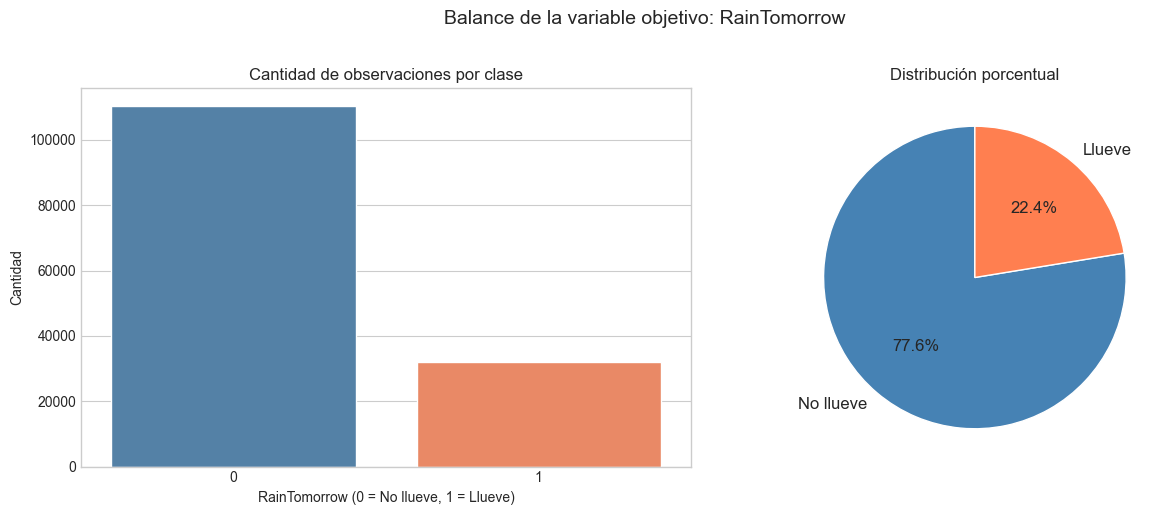

In [83]:
# Visualización del desbalance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot
sns.countplot(x=df['RainTomorrow'], ax=axes[0],
              hue=df['RainTomorrow'],
              palette={0: 'steelblue', 1: 'coral'},
              legend=False)
axes[0].set_title('Cantidad de observaciones por clase')
axes[0].set_xlabel('RainTomorrow (0 = No llueve, 1 = Llueve)')
axes[0].set_ylabel('Cantidad')

# Pie chart
axes[1].pie(counts,
            labels=['No llueve', 'Llueve'],
            colors=['steelblue', 'coral'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Distribución porcentual')

plt.suptitle('Balance de la variable objetivo: RainTomorrow', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [84]:
df.head(1)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,DayOfYear,Month,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,Region,Region_BOM
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,0,0,336,12,-0.478734,0.87796,-2.449294e-16,1.0,3,Templada


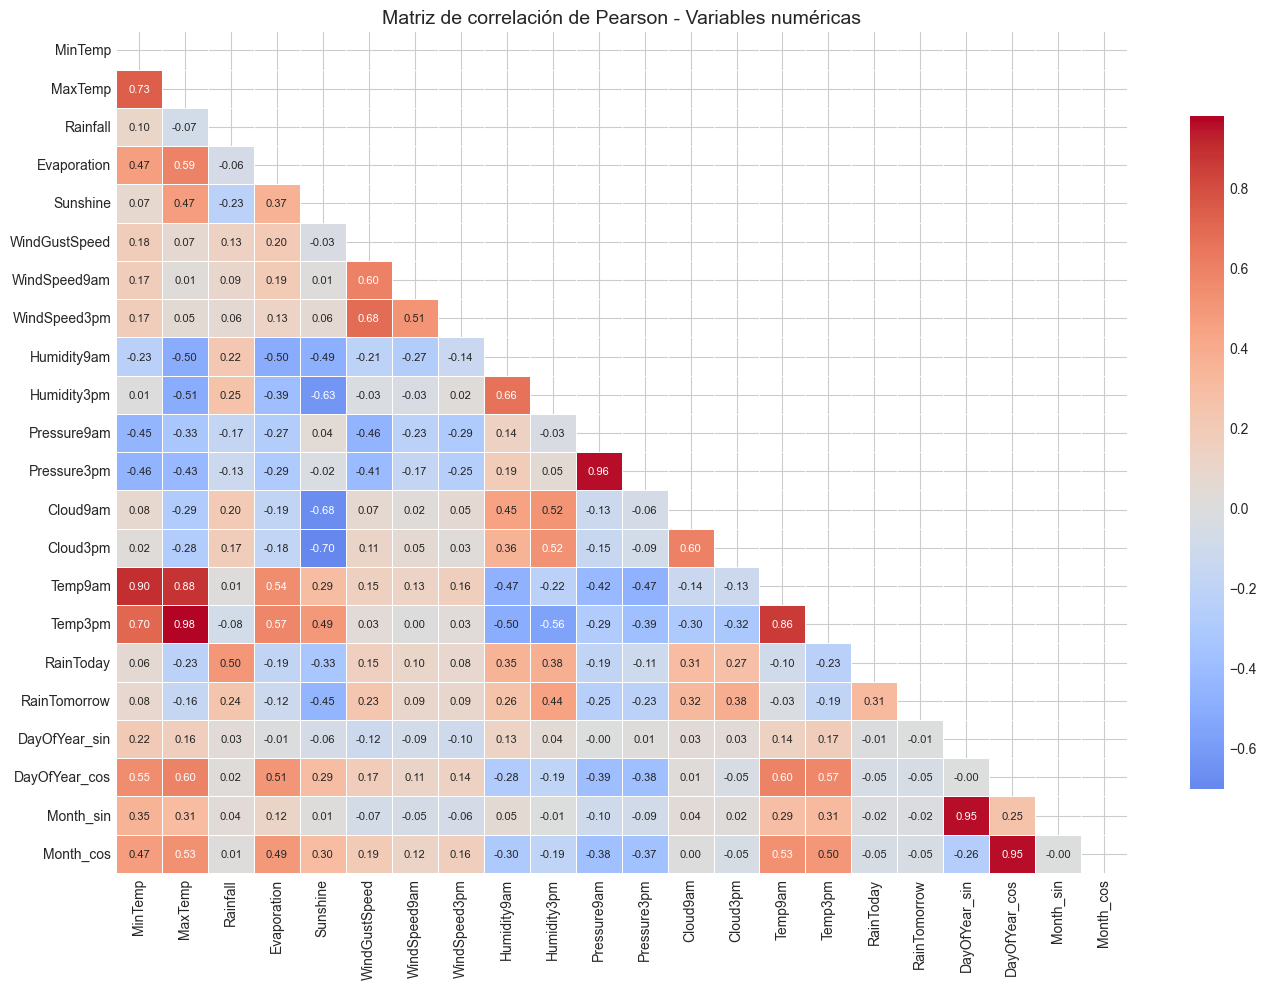

In [85]:
# Seleccionamos las variables numéricas para la matriz de correlación
# Excluimos las direcciones de viento (todavía categóricas) y Region (categórica)
columnas_correlacion = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                        'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                        'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                        'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
                        'RainToday', 'RainTomorrow',
                        'DayOfYear_sin', 'DayOfYear_cos','Month_sin',	'Month_cos']

# Calculamos correlación de Pearson
corr_matrix = df[columnas_correlacion].corr(method='pearson')

# Heatmap completo
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # triángulo superior oculto
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación de Pearson - Variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

Se observa alta correlación positiva entre MinTemp y MaxTemp, y entre Temp9am y Temp3pm, lo cual es esperable porque describen distintas mediciones de temperatura del mismo día.

Humidity3pm y Humidity9am también presentan una correlación elevada, indicando que aportan información similar.

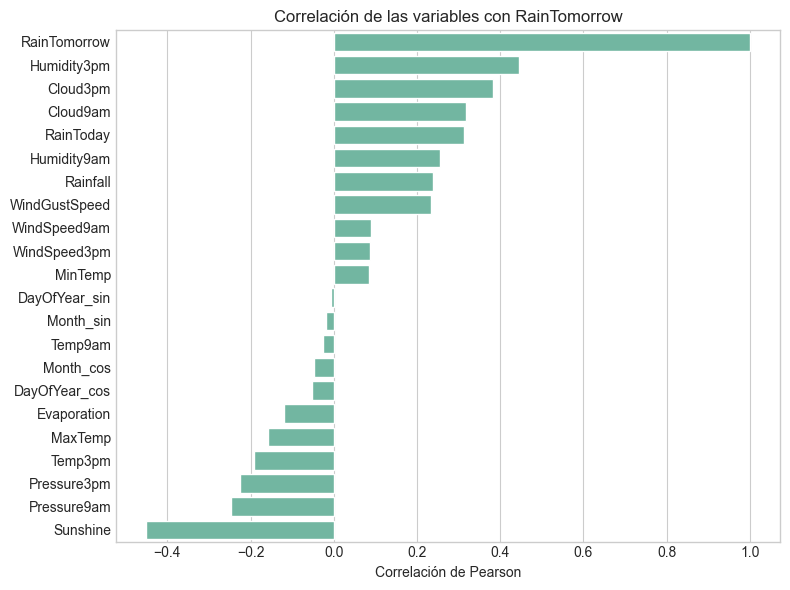

In [86]:
# Correlación de todas las features con la variable objetivo
corr_target = corr_matrix['RainTomorrow'].sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title("Correlación de las variables con RainTomorrow")
plt.xlabel("Correlación de Pearson")
plt.ylabel("")
plt.tight_layout()
plt.show()



Respecto de la variable objetivo RainTomorrow, las variables con mayor correlación positiva son RainToday, Humidity3pm y Cloud3pm, lo que es consistente con la intuición: si hoy llueve, la humedad a la tarde es alta y el cielo está nublado, aumenta la probabilidad de lluvia al día siguiente.

La mayoría de las demás variables tienen correlaciones débiles (cerca de 0), por lo que su relación lineal con la lluvia de mañana es baja. Esto no implica que sean inútiles, pero sí que, al menos bajo una medida lineal (Pearson), no aportan tanta información.

In [87]:
# Correlación específica con la target, ordenada
corr_target = corr_matrix['RainTomorrow'].drop('RainTomorrow').sort_values(key=abs, ascending=False)
print('Correlaciones con RainTomorrow (ordenadas por valor absoluto):\n')
print(corr_target.round(3))

Correlaciones con RainTomorrow (ordenadas por valor absoluto):

Sunshine        -0.451
Humidity3pm      0.445
Cloud3pm         0.382
Cloud9am         0.317
RainToday        0.313
Humidity9am      0.256
Pressure9am     -0.246
Rainfall         0.239
WindGustSpeed    0.233
Pressure3pm     -0.226
Temp3pm         -0.192
MaxTemp         -0.159
Evaporation     -0.119
WindSpeed9am     0.090
WindSpeed3pm     0.088
MinTemp          0.084
DayOfYear_cos   -0.051
Month_cos       -0.046
Temp9am         -0.025
Month_sin       -0.019
DayOfYear_sin   -0.007
Name: RainTomorrow, dtype: float64


In [88]:
df.head(1)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,DayOfYear,Month,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,Region,Region_BOM
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,0,0,336,12,-0.478734,0.87796,-2.449294e-16,1.0,3,Templada


In [89]:
df = df.drop(columns=['Date', 'Location','DayOfYear','Month', 'Region'])

df.head(1)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,Region_BOM
0,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,0,0,-0.478734,0.87796,-2.449294e-16,1.0,Templada


In [90]:
from sklearn.model_selection import train_test_split

# Separamos features y target
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# Split estratificado por la target (importante por el desbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificamos las dimensiones
print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

# Verificamos que stratify mantuvo las proporciones de la target
print('\nProporción de clases en y_train:')
print(y_train.value_counts(normalize=True).round(4))
print('\nProporción de clases en y_test:')
print(y_test.value_counts(normalize=True).round(4))

X_train: (113722, 25)
X_test:  (28431, 25)
y_train: (113722,)
y_test:  (28431,)

Proporción de clases en y_train:
RainTomorrow
0    0.7758
1    0.2242
Name: proportion, dtype: float64

Proporción de clases en y_test:
RainTomorrow
0    0.7758
1    0.2242
Name: proportion, dtype: float64


In [91]:
# Diccionario: dirección → ángulo en grados (16 puntos cardinales)
direccion_a_grados = {
    'N':   0,    'NNE': 22.5,  'NE':  45,    'ENE': 67.5,
    'E':   90,   'ESE': 112.5, 'SE':  135,   'SSE': 157.5,
    'S':   180,  'SSW': 202.5, 'SW':  225,   'WSW': 247.5,
    'W':   270,  'WNW': 292.5, 'NW':  315,   'NNW': 337.5
}

def codificar_direccion_ciclica(df, columna):
    """Codifica una columna de direcciones cardinales con sin/cos."""
    grados = df[columna].map(direccion_a_grados)
    radianes = np.deg2rad(grados)

    df[f'{columna}_sin'] = np.sin(radianes)
    df[f'{columna}_cos'] = np.cos(radianes)
    df.drop(columns=[columna], inplace=True)
    return df

# Aplicamos a train y test por separado
# (es determinística, pero por consistencia con la metodología, post-split)
columnas_viento = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in columnas_viento:
    X_train = codificar_direccion_ciclica(X_train, col)
    X_test = codificar_direccion_ciclica(X_test, col)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print('\nColumnas nuevas en X_train:')
print([c for c in X_train.columns if 'sin' in c or 'cos' in c])
X_train.head()

X_train shape: (113722, 28)
X_test shape: (28431, 28)

Columnas nuevas en X_train:
['DayOfYear_sin', 'DayOfYear_cos', 'Month_sin', 'Month_cos', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos']


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,Region_BOM,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos
62456,11.9,25.4,0.0,NaN,NaN,78.0,32.0,37.0,65.2,41.1,1015.6,1012.5,4.0,NaN,16.0,24.4,0,-0.994218,0.107381,-8.660254e-01,0.500000,Templada,-0.923880,-3.826834e-01,-1.000000e+00,-1.836970e-16,-0.707107,7.071068e-01
84817,14.2,22.9,24.8,4.2,3.8,36.0,7.0,8.0,77.7,60.9,1025.2,1021.7,6.0,7.0,17.9,21.7,1,0.280231,-0.959933,1.224647e-16,-1.000000,Subtropical,0.707107,-7.071068e-01,-7.071068e-01,-7.071068e-01,0.382683,-9.238795e-01
87834,19.1,27.9,0.0,NaN,NaN,41.0,24.0,31.0,45.3,54.0,1018.5,1015.9,NaN,NaN,23.8,25.6,0,-0.137279,0.990532,-2.449294e-16,1.000000,Subtropical,0.923880,-3.826834e-01,1.224647e-16,-1.000000e+00,0.707107,-7.071068e-01
85865,20.6,30.5,0.0,7.0,8.5,31.0,16.0,24.0,62.8,56.4,1012.5,1010.0,7.0,8.0,26.5,27.6,0,-0.831171,0.556017,-5.000000e-01,0.866025,Tropical,1.000000,6.123234e-17,3.826834e-01,-9.238795e-01,1.000000,6.123234e-17
69225,21.5,37.5,0.0,12.0,6.7,41.0,11.0,26.0,29.3,21.1,1013.0,1011.9,7.0,7.0,28.8,35.1,0,0.051620,0.998667,5.000000e-01,0.866025,Pastizales,-0.707107,7.071068e-01,-7.071068e-01,7.071068e-01,-0.923880,-3.826834e-01


Se transforman las regiones en dummies

In [92]:
from sklearn.preprocessing import OneHotEncoder

# Se crea el encoder
ohe_region = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

region_train_encoded = ohe_region.fit_transform(X_train[['Region_BOM']])
col_names_encoded = [f'Region_{cat}' for cat in ohe_region.categories_[0][1:]]
df_region_train = pd.DataFrame(region_train_encoded, columns=col_names_encoded, index=X_train.index)

region_test_encoded = ohe_region.transform(X_test[['Region_BOM']])
df_region_test = pd.DataFrame(region_test_encoded, columns=col_names_encoded, index=X_test.index)

# Se Reemplaza la columna de texto original por las nuevas columnas numéricas
X_train = pd.concat([X_train.drop(columns=['Region_BOM']), df_region_train], axis=1)
X_test = pd.concat([X_test.drop(columns=['Region_BOM']), df_region_test], axis=1)

X_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,DayOfYear_sin,DayOfYear_cos,Month_sin,Month_cos,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,Region_Montañoso,Region_Oceánica,Region_Pastizales,Region_Subtropical,Region_Templada,Region_Tropical
62456,11.9,25.4,0.0,NaN,NaN,78.0,32.0,37.0,65.2,41.1,1015.6,1012.5,4.0,NaN,16.0,24.4,0,-0.994218,0.107381,-8.660254e-01,0.500000,-0.923880,-3.826834e-01,-1.000000e+00,-1.836970e-16,-0.707107,7.071068e-01,0.0,0.0,0.0,0.0,1.0,0.0
84817,14.2,22.9,24.8,4.2,3.8,36.0,7.0,8.0,77.7,60.9,1025.2,1021.7,6.0,7.0,17.9,21.7,1,0.280231,-0.959933,1.224647e-16,-1.000000,0.707107,-7.071068e-01,-7.071068e-01,-7.071068e-01,0.382683,-9.238795e-01,0.0,0.0,0.0,1.0,0.0,0.0
87834,19.1,27.9,0.0,NaN,NaN,41.0,24.0,31.0,45.3,54.0,1018.5,1015.9,NaN,NaN,23.8,25.6,0,-0.137279,0.990532,-2.449294e-16,1.000000,0.923880,-3.826834e-01,1.224647e-16,-1.000000e+00,0.707107,-7.071068e-01,0.0,0.0,0.0,1.0,0.0,0.0
85865,20.6,30.5,0.0,7.0,8.5,31.0,16.0,24.0,62.8,56.4,1012.5,1010.0,7.0,8.0,26.5,27.6,0,-0.831171,0.556017,-5.000000e-01,0.866025,1.000000,6.123234e-17,3.826834e-01,-9.238795e-01,1.000000,6.123234e-17,0.0,0.0,0.0,0.0,0.0,1.0
69225,21.5,37.5,0.0,12.0,6.7,41.0,11.0,26.0,29.3,21.1,1013.0,1011.9,7.0,7.0,28.8,35.1,0,0.051620,0.998667,5.000000e-01,0.866025,-0.707107,7.071068e-01,-7.071068e-01,7.071068e-01,-0.923880,-3.826834e-01,0.0,0.0,1.0,0.0,0.0,0.0


In [93]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Definimos los grupos
cols_mediana = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindSpeed9am', 'WindSpeed3pm',
                'Humidity9am', 'Humidity3pm', 'Temp9am', 'Temp3pm', 'RainToday',
                'WindGustDir_sin', 'WindGustDir_cos',
                'WindDir9am_sin', 'WindDir9am_cos',
                'WindDir3pm_sin', 'WindDir3pm_cos']

cols_knn = ['Pressure9am', 'Pressure3pm', 'WindGustSpeed']

cols_iterative = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']

# === Imputación con MEDIANA ===
imputer_mediana = SimpleImputer(strategy='median')
X_train[cols_mediana] = imputer_mediana.fit_transform(X_train[cols_mediana])
X_test[cols_mediana] = imputer_mediana.transform(X_test[cols_mediana])

print('✅ Mediana aplicada')

# Imputación con KNN.
imputer_knn = KNNImputer(n_neighbors=5)
X_train[cols_knn] = imputer_knn.fit_transform(X_train[cols_knn])
X_test[cols_knn] = imputer_knn.transform(X_test[cols_knn])

print('✅ KNN aplicada')

# === Imputación con ITERATIVE ===
# Iterative usa las otras variables para predecir los nulos
# Le pasamos todo el dataframe para que tenga más info para trabajar
imputer_iterative = IterativeImputer(random_state=42, max_iter=10)

# Importante: fit/transform sobre TODAS las columnas pero solo guardamos las que nos interesan
X_train_imp = imputer_iterative.fit_transform(X_train)
X_test_imp = imputer_iterative.transform(X_test)

# Volvemos a DataFrame manteniendo las columnas
X_train = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imp, columns=X_test.columns, index=X_test.index)

print('✅ Iterative aplicada')

# Verificamos que no haya nulos
print(f'\nNulos en X_train: {X_train.isnull().sum().sum()}')
print(f'Nulos en X_test: {X_test.isnull().sum().sum()}')

✅ Mediana aplicada
✅ KNN aplicada
✅ Iterative aplicada

Nulos en X_train: 0
Nulos en X_test: 0


In [94]:
X_train.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
       'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'DayOfYear_sin', 'DayOfYear_cos', 'Month_sin', 'Month_cos', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos',
       'WindDir3pm_sin', 'WindDir3pm_cos', 'Region_Montañoso', 'Region_Oceánica', 'Region_Pastizales', 'Region_Subtropical', 'Region_Templada', 'Region_Tropical'],
      dtype='object')

In [95]:
from sklearn.preprocessing import RobustScaler

# Identificamos las columnas que NO hay que escalar
cols_no_escalar = [ 'RainToday',
                    'DayOfYear_sin', 'DayOfYear_cos',
                    'Month_sin', 'Month_cos',
                    'WindGustDir_sin', 'WindGustDir_cos',
                    'WindDir9am_sin', 'WindDir9am_cos',
                    'WindDir3pm_sin', 'WindDir3pm_cos',
                    'Region_Montañoso', 'Region_Oceánica', 'Region_Pastizales',
                    'Region_Subtropical', 'Region_Templada', 'Region_Tropical']

# Las que SÍ escalamos son el resto
cols_a_escalar = [c for c in X_train.columns if c not in cols_no_escalar]

print(f'Columnas a escalar ({len(cols_a_escalar)}):')
print(cols_a_escalar)
print(f'\nColumnas a NO escalar ({len(cols_no_escalar)}):')
print(cols_no_escalar)

Columnas a escalar (16):
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Columnas a NO escalar (17):
['RainToday', 'DayOfYear_sin', 'DayOfYear_cos', 'Month_sin', 'Month_cos', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'Region_Montañoso', 'Region_Oceánica', 'Region_Pastizales', 'Region_Subtropical', 'Region_Templada', 'Region_Tropical']


In [96]:
# Aplicamos RobustScaler: usa mediana y rango intercuartílico (IQR)
# Fórmula: (x - mediana) / IQR
# Resistente a outliers porque mediana e IQR no se ven afectados por valores extremos
scaler = RobustScaler()
X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print('RobustScaler aplicado')

# Verificación: la mediana debería ser ~0 (no la media, porque robust usa mediana)
print(f'\nMediana e IQR de las columnas escaladas en X_train:')
print(X_train[cols_a_escalar].agg(['median']).T.round(3).head(10))

RobustScaler aplicado

Mediana e IQR de las columnas escaladas en X_train:
               median
MinTemp           0.0
MaxTemp           0.0
Rainfall          0.0
Evaporation       0.0
Sunshine          0.0
WindGustSpeed     0.0
WindSpeed9am      0.0
WindSpeed3pm      0.0
Humidity9am       0.0
Humidity3pm       0.0


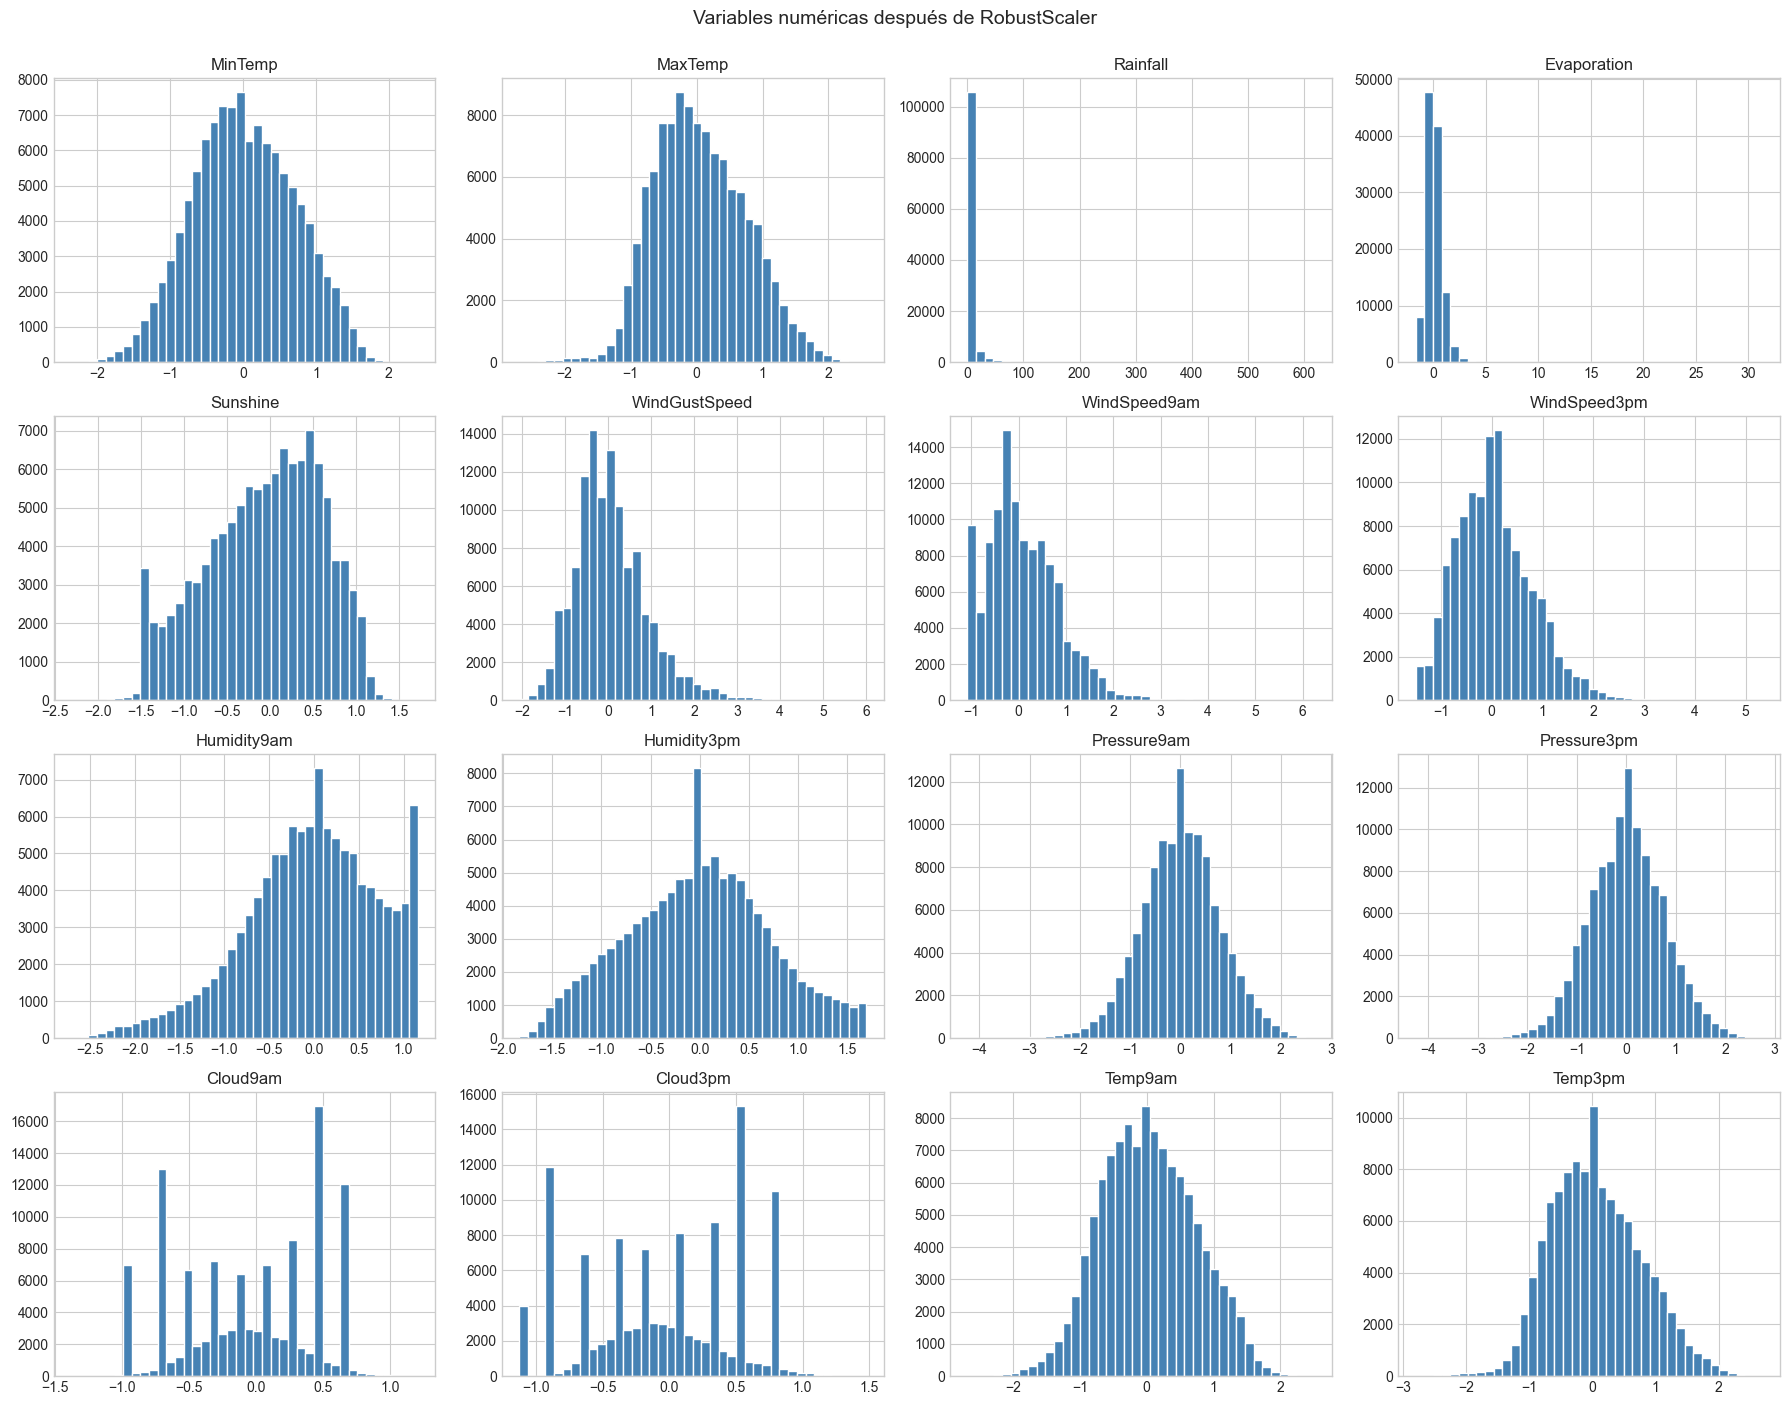

In [97]:
# Visualizamos las distribuciones post-escalado
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_a_escalar):
    axes[i].hist(X_train[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)

# Ocultar ejes vacíos si sobran
for j in range(len(cols_a_escalar), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas después de RobustScaler',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [122]:
# Guardamos los datasets ya procesados
X_train.to_pickle('X_train_procesado.pkl')
X_test.to_pickle('X_test_procesado.pkl')
y_train.to_pickle('y_train.pkl')
y_test.to_pickle('y_test.pkl')

print('✅ Datos guardados. Para recuperarlos en otra sesión:')
print("X_train = pd.read_pickle('X_train_procesado.pkl')")
print("X_test = pd.read_pickle('X_test_procesado.pkl')")
print("y_train = pd.read_pickle('y_train.pkl')")
print("y_test = pd.read_pickle('y_test.pkl')")

✅ Datos guardados. Para recuperarlos en otra sesión:
X_train = pd.read_pickle('X_train_procesado.pkl')
X_test = pd.read_pickle('X_test_procesado.pkl')
y_train = pd.read_pickle('y_train.pkl')
y_test = pd.read_pickle('y_test.pkl')


## Clasificación con Regresión Logística

In [98]:
# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, auc
)

# Split
from sklearn.model_selection import train_test_split

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [99]:
# Recuperamos los datos ya preprocesados
X_train_full = pd.read_pickle('X_train_procesado.pkl')
X_test = pd.read_pickle('X_test_procesado.pkl')
y_train_full = pd.read_pickle('y_train.pkl')
y_test = pd.read_pickle('y_test.pkl')

print(f'X_train_full: {X_train_full.shape}')
print(f'X_test: {X_test.shape}')
print(f'Proporción y_train_full:\n{y_train_full.value_counts(normalize=True).round(3)}')

X_train_full: (113722, 33)
X_test: (28431, 33)
Proporción y_train_full:
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64


In [100]:
# Split estratificado: 80% train / 20% validación (sobre el train_full original)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print(f'X_train: {X_train.shape}  | y_train balance:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'X_val:   {X_val.shape}  | y_val balance:\n{y_val.value_counts(normalize=True).round(3)}')
print(f'X_test:  {X_test.shape}  | y_test balance:\n{y_test.value_counts(normalize=True).round(3)}')

X_train: (90977, 33)  | y_train balance:
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64
X_val:   (22745, 33)  | y_val balance:
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64
X_test:  (28431, 33)  | y_test balance:
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64


In [101]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)
y_val = y_val.astype(int)

print(y_train.dtype)  # debe decir int64

int32


In [102]:
# Instanciamos la regresión logística con class_weight='balanced'
logreg = LogisticRegression(
    penalty='l2',
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Entrenamos sobre train (no sobre train_full)
logreg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [103]:
# Predicciones con umbral por defecto
y_pred_test_05 = logreg.predict(X_test)
y_proba_test = logreg.predict_proba(X_test)[:, 1]  # probabilidad de clase 1 (lluvia)

In [104]:
# Calculamos todas las métricas relevantes
def reporte_metricas(y_true, y_pred, y_proba, nombre='Modelo'):
    print(f'\n{"="*55}')
    print(f'{nombre}')
    print(f'{"="*55}')
    print(f'Accuracy        : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision (pos) : {precision_score(y_true, y_pred):.4f}')
    print(f'Recall (pos)    : {recall_score(y_true, y_pred):.4f}')
    print(f'F1 (pos)        : {f1_score(y_true, y_pred):.4f}')
    print(f'F1 macro        : {f1_score(y_true, y_pred, average="macro"):.4f}')
    print(f'F1 weighted     : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'ROC AUC         : {roc_auc_score(y_true, y_proba):.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['No Lluvia', 'Lluvia']))

reporte_metricas(y_test, y_pred_test_05, y_proba_test, 'Regresión Logística — Umbral 0.5')


Regresión Logística — Umbral 0.5
Accuracy        : 0.7888
Precision (pos) : 0.5194
Recall (pos)    : 0.7731
F1 (pos)        : 0.6214
F1 macro        : 0.7374
F1 weighted     : 0.8015
ROC AUC         : 0.8688

Classification Report:
              precision    recall  f1-score   support

   No Lluvia       0.92      0.79      0.85     22057
      Lluvia       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



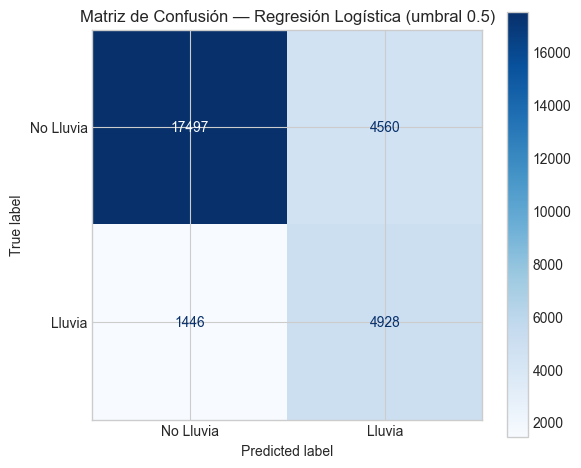


Verdaderos Negativos (TN): 17497  - Predijo "No llueve" y no llovió
Falsos Positivos    (FP):  4560  - Predijo "llueve" pero NO llovió
Falsos Negativos    (FN):  1446  - Predijo "No llueve" pero SÍ llovió
Verdaderos Positivos(TP):  4928  - Predijo "llueve" y llovió


In [105]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test_05)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Lluvia', 'Lluvia'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusión — Regresión Logística (umbral 0.5)')
plt.tight_layout()
plt.show()

print(f'\nVerdaderos Negativos (TN): {tn:>5}  - Predijo "No llueve" y no llovió')
print(f'Falsos Positivos    (FP): {fp:>5}  - Predijo "llueve" pero NO llovió')
print(f'Falsos Negativos    (FN): {fn:>5}  - Predijo "No llueve" pero SÍ llovió')
print(f'Verdaderos Positivos(TP): {tp:>5}  - Predijo "llueve" y llovió')

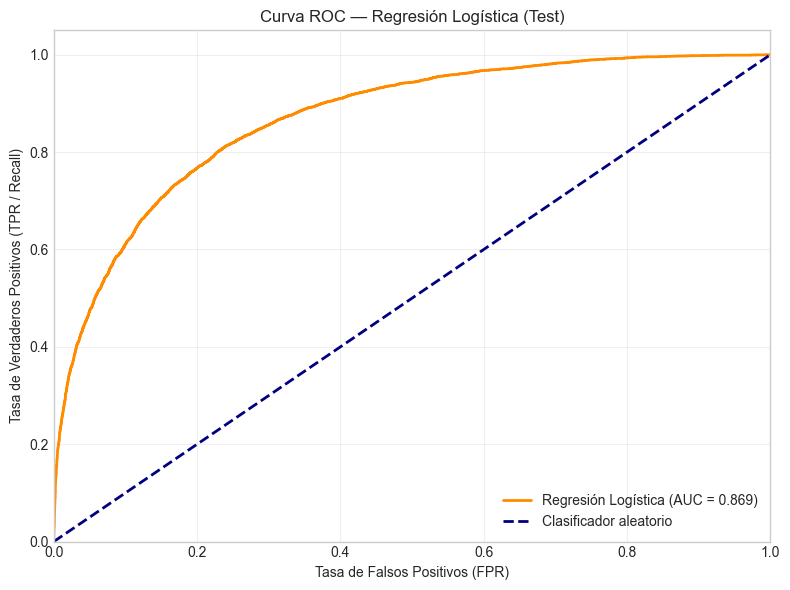

In [106]:
# Curva ROC sobre test
fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test)
auc_test = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
         label=f'Regresión Logística (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC — Regresión Logística (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [107]:
# Predicciones de probabilidad sobre validación
y_proba_val = logreg.predict_proba(X_val)[:, 1]

# Generamos un rango de umbrales y calculamos F1 macro para cada uno
thresholds_eval = np.linspace(0.01, 0.99, 99)

f1_macro_vals = []
f1_pos_vals = []
for thr in thresholds_eval:
    y_pred_thr = (y_proba_val >= thr).astype(int)
    f1_macro_vals.append(f1_score(y_val, y_pred_thr, average='macro'))
    f1_pos_vals.append(f1_score(y_val, y_pred_thr))

# Umbral óptimo según F1 macro
idx_opt_macro = np.argmax(f1_macro_vals)
thr_opt_macro = thresholds_eval[idx_opt_macro]
print(f'Umbral óptimo (F1 macro)    : {thr_opt_macro:.3f}  |  F1 macro val: {f1_macro_vals[idx_opt_macro]:.4f}')

# Umbral óptimo según F1 de la clase positiva (para comparar)
idx_opt_pos = np.argmax(f1_pos_vals)
thr_opt_pos = thresholds_eval[idx_opt_pos]
print(f'Umbral óptimo (F1 positiva) : {thr_opt_pos:.3f}  |  F1 pos val:   {f1_pos_vals[idx_opt_pos]:.4f}')

Umbral óptimo (F1 macro)    : 0.680  |  F1 macro val: 0.7569
Umbral óptimo (F1 positiva) : 0.580  |  F1 pos val:   0.6300



Regresión Logística — Umbral óptimo 0.640
Accuracy        : 0.8283
Precision (pos) : 0.6073
Recall (pos)    : 0.6630
F1 (pos)        : 0.6339
F1 macro        : 0.7609
F1 weighted     : 0.8309
ROC AUC         : 0.8688

Classification Report:
              precision    recall  f1-score   support

   No Lluvia       0.90      0.88      0.89     22057
      Lluvia       0.61      0.66      0.63      6374

    accuracy                           0.83     28431
   macro avg       0.75      0.77      0.76     28431
weighted avg       0.83      0.83      0.83     28431



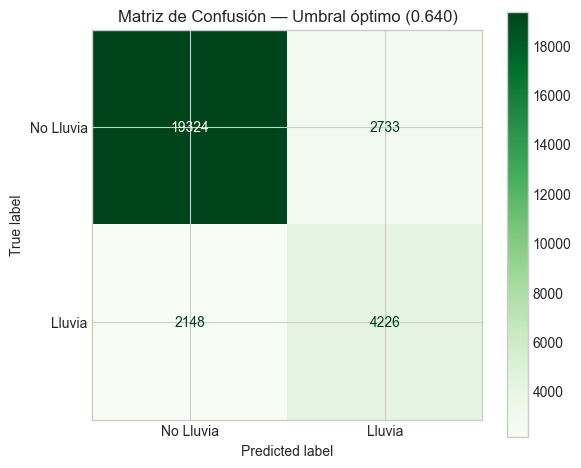


Con umbral óptimo (0.640):
TN: 19324, FP: 2733, FN: 2148, TP: 4226


In [108]:
# Aplicamos el umbral óptimo (encontrado en validación) sobre test
thr_opt_macro = 0.640  # de la celda anterior
y_pred_test_opt = (y_proba_test >= thr_opt_macro).astype(int)

reporte_metricas(y_test, y_pred_test_opt, y_proba_test,
                 f'Regresión Logística — Umbral óptimo {thr_opt_macro:.3f}')

# Matriz de confusión con umbral óptimo
cm_opt = confusion_matrix(y_test, y_pred_test_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['No Lluvia', 'Lluvia'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'Matriz de Confusión — Umbral óptimo ({thr_opt_macro:.3f})')
plt.tight_layout()
plt.show()

print(f'\nCon umbral óptimo ({thr_opt_macro:.3f}):')
print(f'TN: {tn_o}, FP: {fp_o}, FN: {fn_o}, TP: {tp_o}')

In [109]:
# Tabla comparativa
print(f"\n{'Métrica':<20} {'Umbral 0.5':<15} {'Umbral '+f'{thr_opt_macro:.3f}':<15}")
print('-'*55)
print(f"{'Accuracy':<20} {accuracy_score(y_test, y_pred_test_05):<15.4f} {accuracy_score(y_test, y_pred_test_opt):<15.4f}")
print(f"{'Precision (pos)':<20} {precision_score(y_test, y_pred_test_05):<15.4f} {precision_score(y_test, y_pred_test_opt):<15.4f}")
print(f"{'Recall (pos)':<20} {recall_score(y_test, y_pred_test_05):<15.4f} {recall_score(y_test, y_pred_test_opt):<15.4f}")
print(f"{'F1 (pos)':<20} {f1_score(y_test, y_pred_test_05):<15.4f} {f1_score(y_test, y_pred_test_opt):<15.4f}")
print(f"{'F1 macro':<20} {f1_score(y_test, y_pred_test_05, average='macro'):<15.4f} {f1_score(y_test, y_pred_test_opt, average='macro'):<15.4f}")


Métrica              Umbral 0.5      Umbral 0.640   
-------------------------------------------------------
Accuracy             0.7888          0.8283         
Precision (pos)      0.5194          0.6073         
Recall (pos)         0.7731          0.6630         
F1 (pos)             0.6214          0.6339         
F1 macro             0.7374          0.7609         


In [110]:
# Predicciones en train y validación con umbral 0.5
y_pred_train_05 = logreg.predict(X_train)
y_pred_val_05 = logreg.predict(X_val)

# F1 macro en los tres conjuntos
f1_train_05 = f1_score(y_train, y_pred_train_05, average='macro')
f1_val_05 = f1_score(y_val, y_pred_val_05, average='macro')
f1_test_05 = f1_score(y_test, y_pred_test_05, average='macro')

# Con umbral óptimo
y_proba_train = logreg.predict_proba(X_train)[:, 1]
y_proba_val = logreg.predict_proba(X_val)[:, 1]
y_pred_train_opt = (y_proba_train >= thr_opt_macro).astype(int)
y_pred_val_opt = (y_proba_val >= thr_opt_macro).astype(int)

f1_train_opt = f1_score(y_train, y_pred_train_opt, average='macro')
f1_val_opt = f1_score(y_val, y_pred_val_opt, average='macro')
f1_test_opt = f1_score(y_test, y_pred_test_opt, average='macro')

# Tabla comparativa
print(f"{'Métrica':<15} {'Train':<10} {'Val':<10} {'Test':<10}")
print('-' * 45)
print(f"{'F1 macro 0.5':<15} {f1_train_05:<10.4f} {f1_val_05:<10.4f} {f1_test_05:<10.4f}")
print(f"{'F1 macro opt':<15} {f1_train_opt:<10.4f} {f1_val_opt:<10.4f} {f1_test_opt:<10.4f}")

# AUC en los tres
auc_train = roc_auc_score(y_train, y_proba_train)
auc_val = roc_auc_score(y_val, y_proba_val)
auc_test = roc_auc_score(y_test, y_proba_test)
print(f"{'ROC AUC':<15} {auc_train:<10.4f} {auc_val:<10.4f} {auc_test:<10.4f}")

Métrica         Train      Val        Test      
---------------------------------------------
F1 macro 0.5    0.7387     0.7386     0.7374    
F1 macro opt    0.7608     0.7541     0.7609    
ROC AUC         0.8684     0.8657     0.8688    



Modelo Base — DummyClassifier (stratified)
Accuracy        : 0.6555
Precision (pos) : 0.2301
Recall (pos)    : 0.2287
F1 (pos)        : 0.2294
F1 macro        : 0.5038
F1 weighted     : 0.6552
ROC AUC         : 0.5038

Classification Report:
              precision    recall  f1-score   support

   No Lluvia       0.78      0.78      0.78     22057
      Lluvia       0.23      0.23      0.23      6374

    accuracy                           0.66     28431
   macro avg       0.50      0.50      0.50     28431
weighted avg       0.65      0.66      0.66     28431



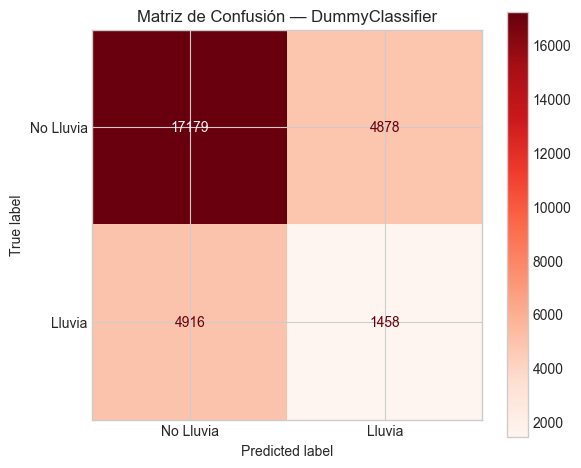

In [111]:
# Modelo base: predice siguiendo la distribución de clases observada
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

# Predicciones
y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

# Métricas
reporte_metricas(y_test, y_pred_dummy, y_proba_dummy, 'Modelo Base — DummyClassifier (stratified)')

# Matriz de confusión
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=['No Lluvia', 'Lluvia'])
disp.plot(ax=ax, cmap='Reds', values_format='d')
ax.set_title('Matriz de Confusión — DummyClassifier')
plt.tight_layout()
plt.show()

In [96]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Hiperparámetros a optimizar
    C = trial.suggest_float('C', 1e-3, 1e3, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    
    # l1_ratio solo tiene sentido si penalty es elasticnet
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    elif penalty == 'l1':
        l1_ratio = 1.0
    else:  # l2
        l1_ratio = 0.0
    
    model = LogisticRegression(
        C=C,
        l1_ratio=l1_ratio,
        solver='saga',       # saga soporta l1, l2 y elasticnet
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

# Crear y correr el estudio
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Optimización completa')
print(f'Mejor F1 macro (CV): {study.best_value:.4f}')
print(f'Mejores hiperparámetros: {study.best_params}')



"""
    SALIDA OPTUBA (NO CORRER)
    ✅ Optimización completa
    Mejor F1 macro (CV): 0.7385
    Mejores hiperparámetros: {'C': 0.4711666171749898, 'penalty': 'l1'}
"""


SyntaxError: unterminated string literal (detected at line 42) (3080914731.py, line 42)

In [97]:
# Entrenamos el modelo final con los mejores hiperparámetros encontrados por Optuna
best_params = study.best_params

# l1_ratio según penalty
if best_params['penalty'] == 'elasticnet':
    l1_ratio = best_params['l1_ratio']
elif best_params['penalty'] == 'l1':
    l1_ratio = 1.0
else:
    l1_ratio = 0.0

logreg_optuna = LogisticRegression(
    C=best_params['C'],
    l1_ratio=l1_ratio,
    solver='saga',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

logreg_optuna.fit(X_train, y_train)
print('✅ Modelo optimizado entrenado')
print(f'Parámetros: C={best_params["C"]:.4f}, penalty={best_params["penalty"]}, l1_ratio={l1_ratio}')

✅ Modelo optimizado entrenado
Parámetros: C=0.4712, penalty=l1, l1_ratio=1.0


In [98]:
# Evaluamos el modelo optimizado en test con umbral 0.5
y_pred_optuna = logreg_optuna.predict(X_test)
y_prob_optuna = logreg_optuna.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

print('='*55)
print('Regresión Logística Optimizada (Optuna) — Umbral 0.5')
print('='*55)
print(f'Accuracy        : {accuracy_score(y_test, y_pred_optuna):.4f}')
print(f'Precision (pos) : {precision_score(y_test, y_pred_optuna):.4f}')
print(f'Recall (pos)    : {recall_score(y_test, y_pred_optuna):.4f}')
print(f'F1 (pos)        : {f1_score(y_test, y_pred_optuna):.4f}')
print(f'F1 macro        : {f1_score(y_test, y_pred_optuna, average="macro"):.4f}')
print(f'ROC AUC         : {roc_auc_score(y_test, y_prob_optuna):.4f}')
print()
print(classification_report(y_test, y_pred_optuna, target_names=['No Lluvia', 'Lluvia']))

Regresión Logística Optimizada (Optuna) — Umbral 0.5
Accuracy        : 0.7889
Precision (pos) : 0.5196
Recall (pos)    : 0.7733
F1 (pos)        : 0.6215
F1 macro        : 0.7376
ROC AUC         : 0.8684

              precision    recall  f1-score   support

   No Lluvia       0.92      0.79      0.85     22057
      Lluvia       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



In [99]:

# Re-optimizamos umbral sobre el validation set
y_prob_val_optuna = logreg_optuna.predict_proba(X_val)[:, 1]

umbrales = np.arange(0.1, 0.9, 0.01)
mejores = {'umbral': 0.5, 'f1_macro': 0}

for u in umbrales:
    y_pred_u = (y_prob_val_optuna >= u).astype(int)
    f1 = f1_score(y_val, y_pred_u, average='macro')
    if f1 > mejores['f1_macro']:
        mejores['f1_macro'] = f1
        mejores['umbral'] = u

umbral_optuna = mejores['umbral']
print(f'Umbral óptimo (Optuna): {umbral_optuna:.3f} | F1 macro val: {mejores["f1_macro"]:.4f}')

# Evaluamos en test con umbral óptimo
y_pred_optuna_umbral = (y_prob_optuna >= umbral_optuna).astype(int)

print()
print('='*55)
print(f'Regresión Logística Optimizada — Umbral {umbral_optuna:.3f}')
print('='*55)
print(f'Accuracy        : {accuracy_score(y_test, y_pred_optuna_umbral):.4f}')
print(f'Precision (pos) : {precision_score(y_test, y_pred_optuna_umbral):.4f}')
print(f'Recall (pos)    : {recall_score(y_test, y_pred_optuna_umbral):.4f}')
print(f'F1 (pos)        : {f1_score(y_test, y_pred_optuna_umbral):.4f}')
print(f'F1 macro        : {f1_score(y_test, y_pred_optuna_umbral, average="macro"):.4f}')
print(f'ROC AUC         : {roc_auc_score(y_test, y_prob_optuna):.4f}')
print()
print(classification_report(y_test, y_pred_optuna_umbral, target_names=['No Lluvia', 'Lluvia']))

Umbral óptimo (Optuna): 0.690 | F1 macro val: 0.7553

Regresión Logística Optimizada — Umbral 0.690
Accuracy        : 0.8346
Precision (pos) : 0.6369
Recall (pos)    : 0.6100
F1 (pos)        : 0.6231
F1 macro        : 0.7586
ROC AUC         : 0.8684

              precision    recall  f1-score   support

   No Lluvia       0.89      0.90      0.89     22057
      Lluvia       0.64      0.61      0.62      6374

    accuracy                           0.83     28431
   macro avg       0.76      0.75      0.76     28431
weighted avg       0.83      0.83      0.83     28431



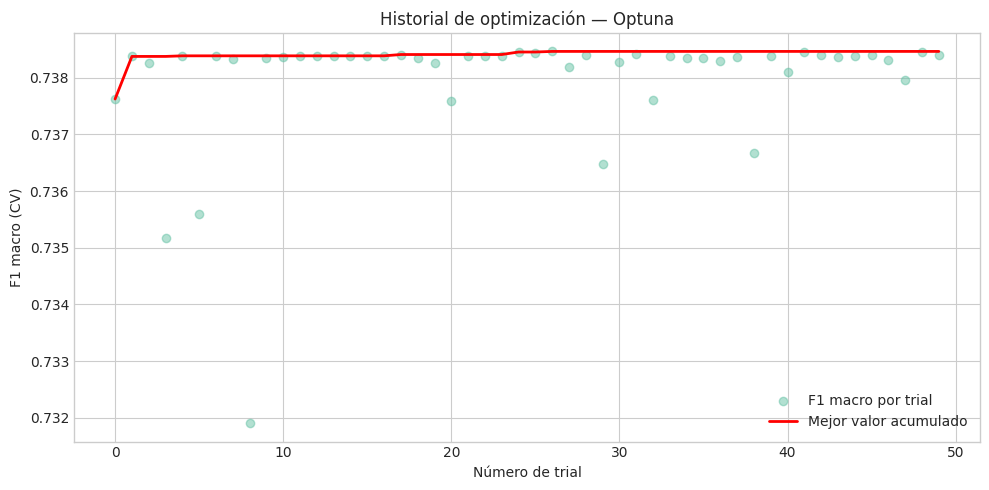

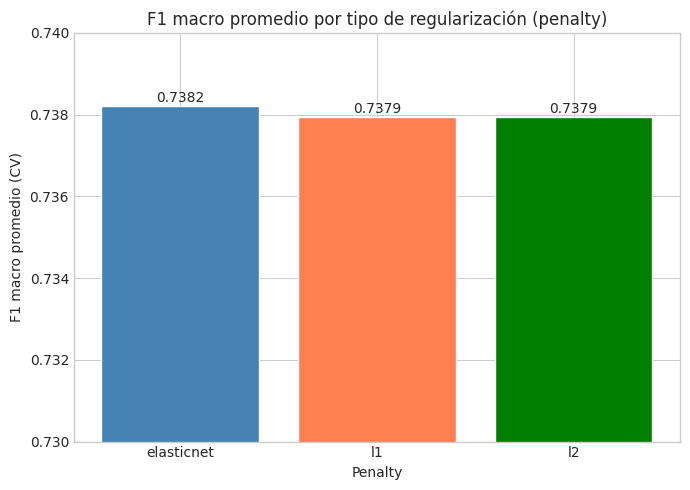

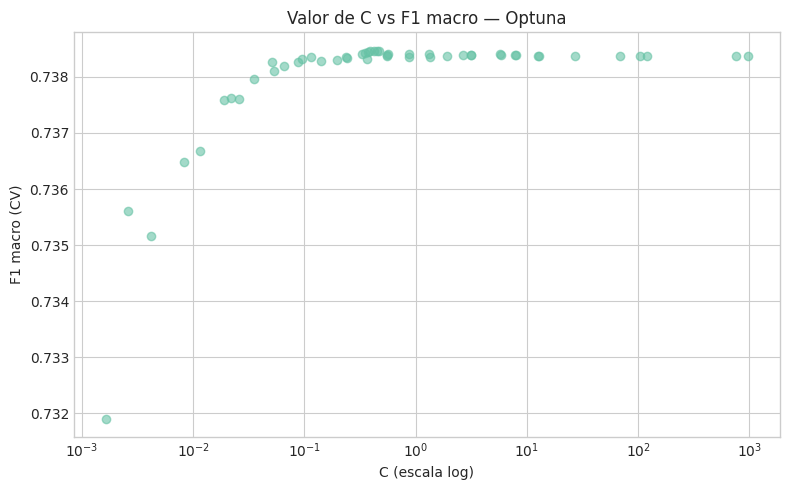

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Extraemos datos del study
trials = study.trials
nums = [t.number for t in trials]
values = [t.value for t in trials]
best_so_far = np.maximum.accumulate(values)

# Gráfica 1: Historial de optimización
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(nums, values, alpha=0.5, label='F1 macro por trial')
ax.plot(nums, best_so_far, color='red', linewidth=2, label='Mejor valor acumulado')
ax.set_title('Historial de optimización — Optuna')
ax.set_xlabel('Número de trial')
ax.set_ylabel('F1 macro (CV)')
ax.legend()
plt.tight_layout()
plt.show()

# Gráfica 2: Importancia de hiperparámetros (manual)
import pandas as pd
rows = []
for t in trials:
    if t.value is not None:
        row = t.params.copy()
        row['f1_macro'] = t.value
        rows.append(row)

df_trials = pd.DataFrame(rows)

# Gráfica 2 corregida: distribución de penalty en los trials
fig, ax = plt.subplots(figsize=(7, 5))
penalty_counts = df_trials.groupby('penalty')['f1_macro'].mean()
bars = ax.bar(penalty_counts.index, penalty_counts.values, color=['steelblue', 'coral', 'green'][:len(penalty_counts)])
ax.set_title('F1 macro promedio por tipo de regularización (penalty)')
ax.set_ylabel('F1 macro promedio (CV)')
ax.set_xlabel('Penalty')
ax.set_ylim(0.73, 0.74)
for bar, val in zip(bars, penalty_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0001, f'{val:.4f}', ha='center')
plt.tight_layout()
plt.show()

# Gráfica 3: C vs F1 macro
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_trials['C'], df_trials['f1_macro'], alpha=0.6)
ax.set_xscale('log')
ax.set_title('Valor de C vs F1 macro — Optuna')
ax.set_xlabel('C (escala log)')
ax.set_ylabel('F1 macro (CV)')
plt.tight_layout()
plt.show()

## Conclusiones — Punto 4

Se utilizó **Optuna** para la optimización de hiperparámetros, con 50 trials y validación 
cruzada StratifiedKFold de 5 folds. Se eligió Optuna sobre GridSearch (muy costoso 
computacionalmente para ~90k filas × 5 folds) y RandomSearch (exploración no dirigida) 
porque usa optimización bayesiana (TPE sampler), aprendiendo de cada trial para dirigir 
la búsqueda hacia zonas prometedoras del espacio de hiperparámetros.

**Hiperparámetros optimizados:**
- `C`: inverso de la regularización — valores bajos penalizan más los coeficientes grandes
- `penalty`: tipo de regularización (l1, l2, elasticnet)
- `l1_ratio`: mezcla entre l1 y l2, solo aplicable cuando penalty='elasticnet'

**Mejores hiperparámetros encontrados:** C=0.471, penalty='l1'

**Resultados:** La mejora sobre el modelo del Punto 2 fue mínima (F1 macro: 0.7373 → 0.7376 
con umbral 0.5), lo que indica que la regresión logística ya se encontraba cerca de su 
rendimiento óptimo. La mayor ganancia provino de re-optimizar el umbral de decisión 
(F1 macro: 0.7373 → 0.7586 con umbral 0.69).

El gráfico de C vs F1 macro muestra que valores de C muy bajos (alta regularización) 
degradan el modelo, mientras que valores altos no aportan mejoras — el óptimo se 
encuentra en la zona intermedia (C ≈ 0.1 a 1).

El gráfico de penalty muestra diferencias despreciables entre los tres tipos de 
regularización (rango de 0.0003), confirmando que este hiperparámetro no es determinante 
para este problema.

In [112]:
import shap

# Creamos el explainer con el modelo optimizado
explainer = shap.LinearExplainer(logreg_optuna, X_train)

# Calculamos SHAP values sobre una muestra del test set
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer(X_test_sample)

print('✅ SHAP values calculados')
print(f'Shape: {shap_values.shape}')

NameError: name 'logreg_optuna' is not defined

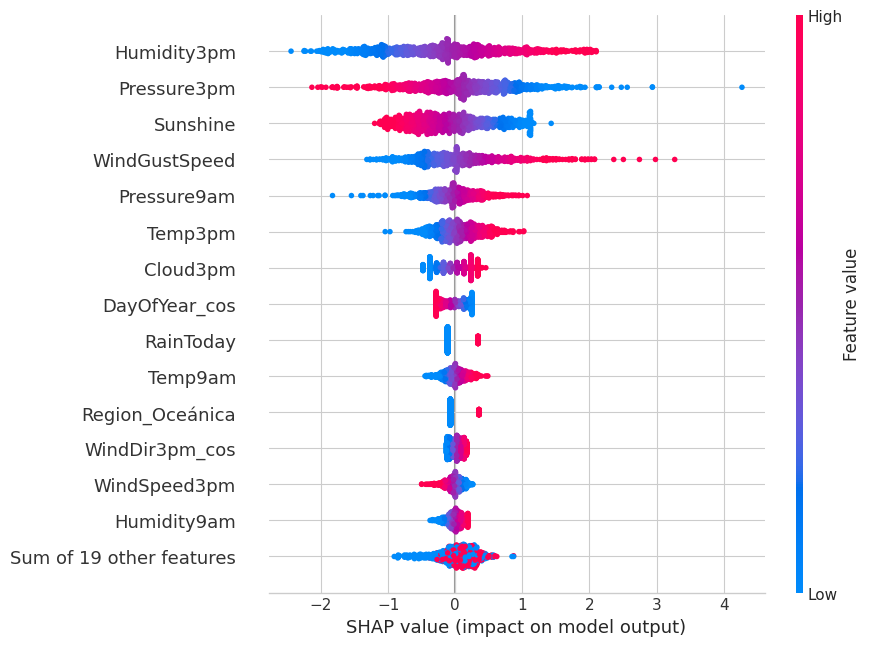

In [106]:
# GLOBAL 1: Beeswarm plot — importancia y dirección del efecto
shap.plots.beeswarm(shap_values, max_display=15, show=True)

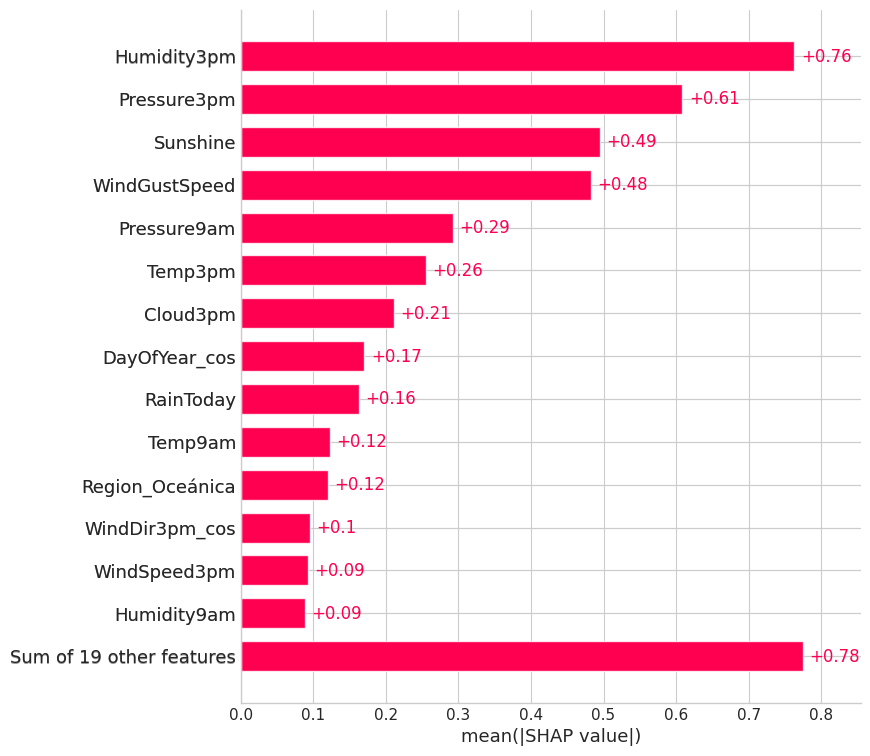

In [107]:
# GLOBAL 2: Bar plot — ranking de importancia media
shap.plots.bar(shap_values, max_display=15, show=True)

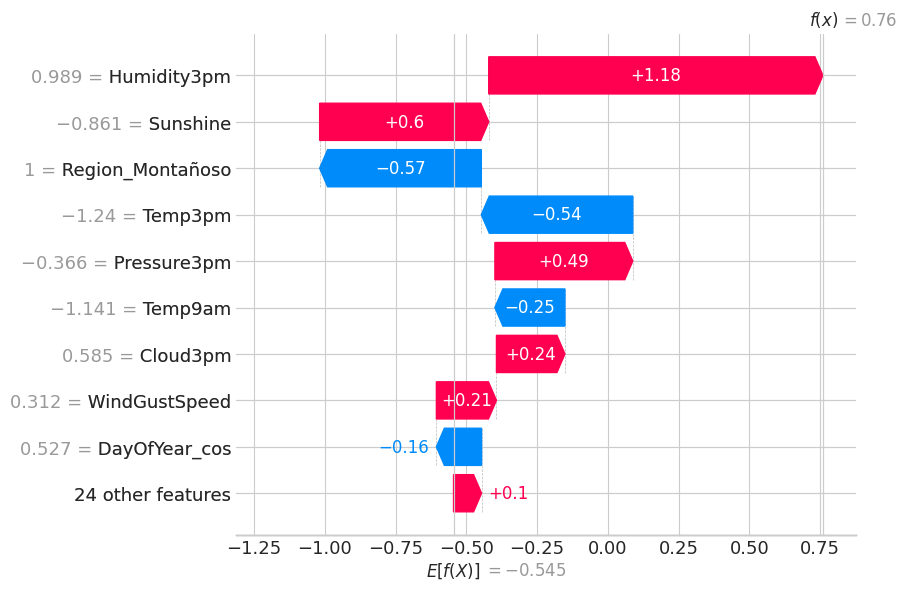

In [108]:
# LOCAL 1: Waterfall plot — explicación de una predicción individual
# Tomamos una observación que el modelo predijo "llueve"
idx_llueve = X_test_sample[logreg_optuna.predict(X_test_sample) == 1].index[0]
pos = X_test_sample.index.get_loc(idx_llueve)

shap.plots.waterfall(shap_values[pos], show=True)

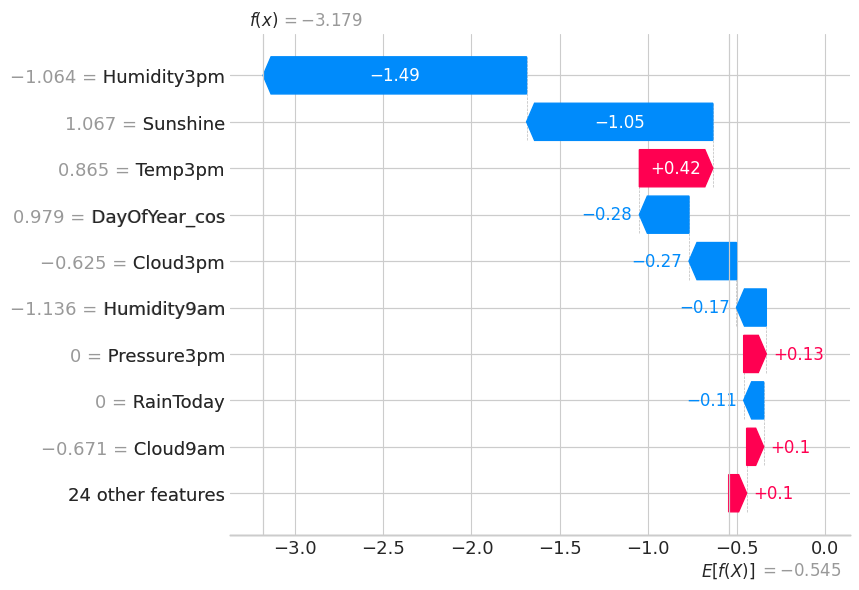

In [109]:
# LOCAL 2: Waterfall de una observación que el modelo predijo "No llueve"
idx_no_llueve = X_test_sample[logreg_optuna.predict(X_test_sample) == 0].index[0]
pos2 = X_test_sample.index.get_loc(idx_no_llueve)

shap.plots.waterfall(shap_values[pos2], show=True)

## Análisis SHAP — Explicabilidad del modelo

### Gráficas globales

**Beeswarm plot:**
La variable más influyente es `Humidity3pm` — valores altos (rojo) generan SHAP values 
positivos grandes (hasta +3), empujando fuertemente hacia "llueve". `Pressure3pm` muestra 
el efecto opuesto: valores altos (rojo) generan SHAP negativos, indicando que alta presión 
atmosférica reduce la probabilidad de lluvia. `Sunshine` también es clave: valores bajos 
(azul) empujan hacia lluvia (+0.6), mientras valores altos la reducen. `WindGustSpeed` 
muestra que ráfagas fuertes (rojo) aumentan la probabilidad de lluvia.

**Bar plot:**
El ranking de importancia media confirma: `Humidity3pm` (0.76), `Pressure3pm` (0.61), 
`Sunshine` (0.49) y `WindGustSpeed` (0.48) son las 4 variables más determinantes. 
Las variables de dirección del viento y región tienen impacto mínimo (< 0.12).

### Gráficas locales

**Waterfall — Predicción "Llueve" (f(x) = 0.76):**
Para esta observación, `Humidity3pm=0.989` (muy alta) aportó +1.18, siendo el factor 
más determinante. `Sunshine=-0.861` (muy baja) sumó +0.6 adicional. En contra actuaron 
`Temp3pm=-1.24` (-0.54) y `Region_Montañoso` (-0.57). El modelo predijo lluvia 
correctamente empujado principalmente por la alta humedad y baja insolación.

**Waterfall — Predicción "No llueve" (f(x) = -3.179):**
Aquí `Humidity3pm=-1.064` (muy baja) aportó -1.49 y `Sunshine=1.067` (alta) sumó -1.05, 
ambas empujando fuertemente hacia "no llueve". `Temp3pm=0.865` fue la única variable 
que empujó levemente hacia lluvia (+0.42) pero insuficiente para revertir el resultado.

### Variables más y menos importantes
- **Más importantes:** Humidity3pm, Pressure3pm, Sunshine, WindGustSpeed
- **Menos importantes:** variables de dirección de viento (WindDir), variables de región, 
  variables de temperatura de la mañana

## Modelo AutoML con PyCaret
Se implementa un enfoque de AutoML utilizando la librería PyCaret, con el objetivo de comparar automáticamente distintos modelos de clasificación y seleccionar el que mejor se desempeñe en la predicción de la variable objetivo (RainTomorrow).

Se construyen los conjuntos de entrenamiento y prueba (train_df_aMl y test_df_aML), combinando las variables predictoras con la variable objetivo. Dado que los conjuntos X_train, y_train, X_test y y_test ya se encuentran imputados y codificados, así PyCaret puede utilizarlos directamente.

In [113]:
train_df_aMl = X_train.copy()
train_df_aMl['RainTomorrow'] = y_train

test_df_aML = X_test.copy()
test_df_aML['RainTomorrow'] = y_test

### Configuración del entorno de AutoML
Se realiza el setup() de PyCaret indicando los parámetros principales. En este caso no se aplica oversampling (SMOTE), ya que el tiempo de ejecución supera los 40 minutos; sin balanceo el tiempo de ejución se redujo a la mitad.

In [114]:
from pycaret.classification import setup, compare_models, pull, predict_model, evaluate_model, plot_model, finalize_model, save_model

#Configuración de entorno de PyCaret
s = setup(
    data=train_df_aMl,
    target='RainTomorrow',
    test_data=test_df_aML,
)

,Description,Value
0,Session id,6734
1,Target,RainTomorrow
2,Target type,Binary
3,Original data shape,"(119408, 34)"
4,Transformed data shape,"(119408, 34)"
5,Transformed train set shape,"(90977, 34)"
6,Transformed test set shape,"(28431, 34)"
7,Numeric features,33
8,Preprocess,True
9,Imputation type,simple


In [115]:
#Comparación de modelos
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8573,0.8871,0.5414,0.7528,0.6298,0.5443,0.5557,0.6800
et,Extra Trees Classifier,0.8570,0.8883,0.5071,0.7778,0.6139,0.5308,0.5492,4.1300
rf,Random Forest Classifier,0.8559,0.8844,0.5100,0.7697,0.6135,0.5294,0.5463,6.2670
gbc,Gradient Boosting Classifier,0.8505,0.8753,0.5119,0.7415,0.6056,0.5172,0.5308,9.4600
lr,Logistic Regression,0.8452,0.8675,0.5083,0.7192,0.5956,0.5034,0.5150,1.4740
ada,Ada Boost Classifier,0.8440,0.8632,0.5007,0.7184,0.5901,0.4975,0.5099,2.2710
lda,Linear Discriminant Analysis,0.8437,0.8655,0.5235,0.7035,0.6003,0.5057,0.5142,0.1680
ridge,Ridge Classifier,0.8433,0.8655,0.4601,0.7433,0.5683,0.4790,0.4996,0.1470
svm,SVM - Linear Kernel,0.8368,0.8486,0.4742,0.7096,0.5587,0.4656,0.4841,0.4550
knn,K Neighbors Classifier,0.8302,0.8220,0.4872,0.6661,0.5627,0.4605,0.4692,4.2560


In [116]:
#Hiperparámetros del mejor modelo
print(best)

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=6734, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [117]:
#Ver leaderboard de mejores modelos
leaderboard = pull()
leaderboard.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8573,0.8871,0.5414,0.7528,0.6298,0.5443,0.5557,0.680
et,Extra Trees Classifier,0.8570,0.8883,0.5071,0.7778,0.6139,0.5308,0.5492,4.130
rf,Random Forest Classifier,0.8559,0.8844,0.5100,0.7697,0.6135,0.5294,0.5463,6.267
gbc,Gradient Boosting Classifier,0.8505,0.8753,0.5119,0.7415,0.6056,0.5172,0.5308,9.460
lr,Logistic Regression,0.8452,0.8675,0.5083,0.7192,0.5956,0.5034,0.5150,1.474


In [118]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

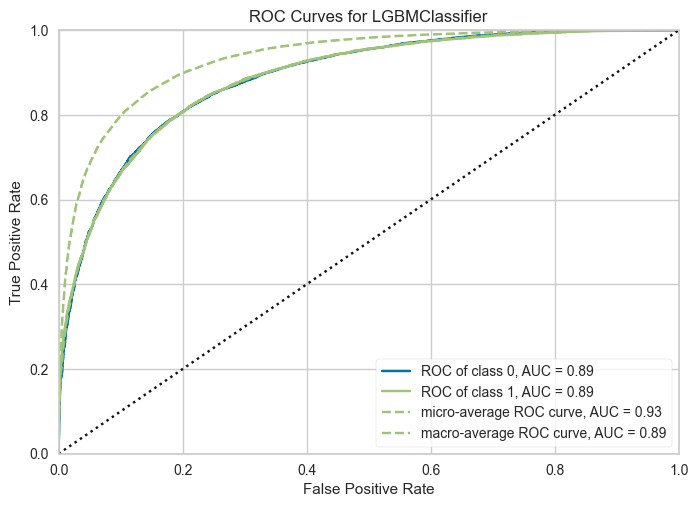

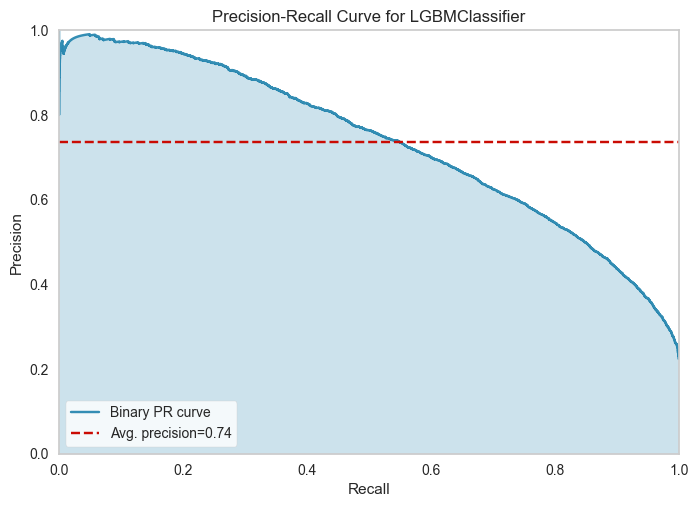

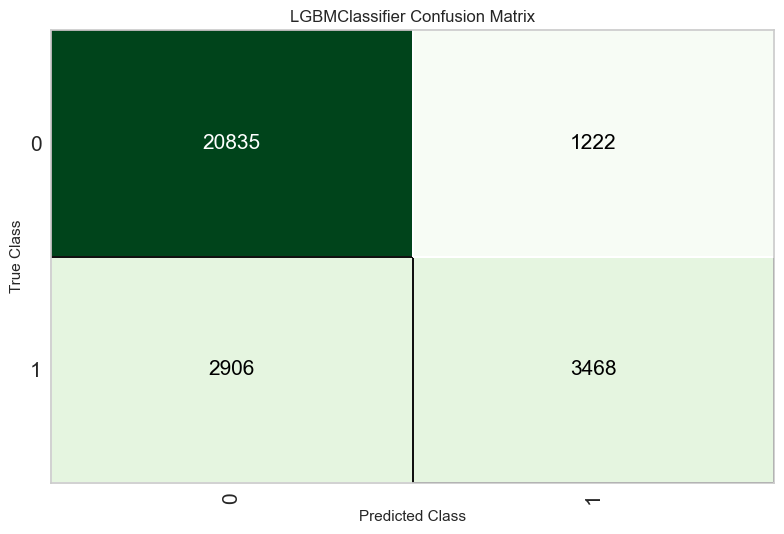

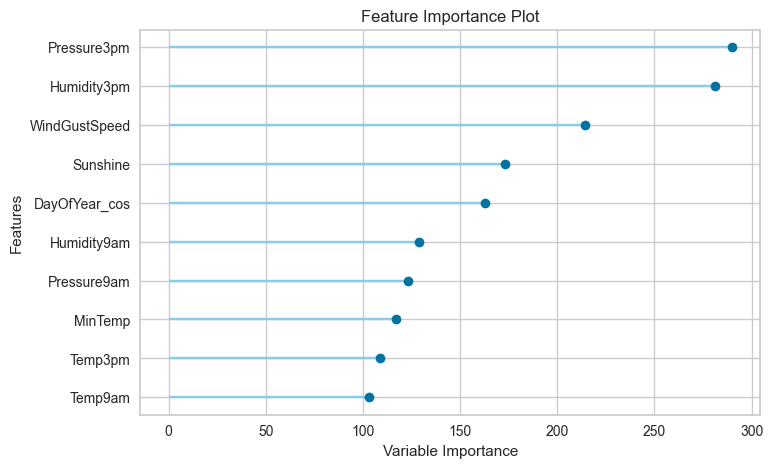

In [119]:
plot_model(best, plot='auc')
plot_model(best, plot='pr')
plot_model(best, plot='confusion_matrix')
plot_model(best, plot='feature') 

In [120]:
pred_test = predict_model(best, data=test_df_aML)
pred_test.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8548,0.8868,0.5441,0.7394,0.6269,0.5393,0.5491


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_cos,Region_Montañoso,Region_Oceánica,Region_Pastizales,Region_Subtropical,Region_Templada,Region_Tropical,RainTomorrow,prediction_label,prediction_score
3085,-0.228261,0.339806,0.000000,0.127882,0.334116,-0.5000,-1.083333,-0.833333,-0.259690,-0.745583,...,9.238795e-01,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0.9506
117789,-0.445652,-0.203883,0.333333,0.000000,0.705901,-0.5625,-0.583333,-0.083333,-0.135659,-0.243816,...,-7.071068e-01,0.0,1.0,0.0,0.0,0.0,0.0,0,0,0.9656
61410,-0.500000,-0.174757,0.000000,0.178977,1.012541,0.1250,-0.500000,1.166667,0.422481,-0.109541,...,6.123234e-17,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0.9918
65144,0.000000,-0.067961,0.000000,0.313210,0.015959,0.1875,0.250000,1.083333,0.282946,-0.151943,...,-9.238795e-01,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0.9403
108868,0.206522,-0.436893,6.333333,-0.092942,-0.415476,1.0750,0.583333,0.000000,0.050388,0.000000,...,-1.836970e-16,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0.5834


### Selección y ajuste del modelo óptimo
Una vez identificado el modelo con mejor desempeño, se realiza un proceso de tuning automático de hiperparámetros mediante la función tune_model(). El objetivo es mejorar la capacidad del modelo para equilibrar precisión y recall.

In [121]:
from pycaret.classification import tune_model, finalize_model
# Afinación del mejor modelo 
tuned = tune_model(best, optimize='Recall', fold= 5)
final  = finalize_model(tuned) 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8463,0.8727,0.5699,0.6907,0.6245,0.5290,0.5329
1,0.8424,0.8640,0.5591,0.6809,0.6140,0.5162,0.5201
2,0.8465,0.8749,0.5757,0.6887,0.6272,0.5315,0.5349
3,0.8467,0.8746,0.5869,0.6842,0.6318,0.5357,0.5382
4,0.8453,0.8724,0.5653,0.6888,0.6210,0.5250,0.5290
Mean,0.8454,0.8717,0.5714,0.6866,0.6237,0.5275,0.5310
Std,0.0016,0.0040,0.0095,0.0036,0.0060,0.0066,0.0062


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [122]:
evaluate_model(final)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

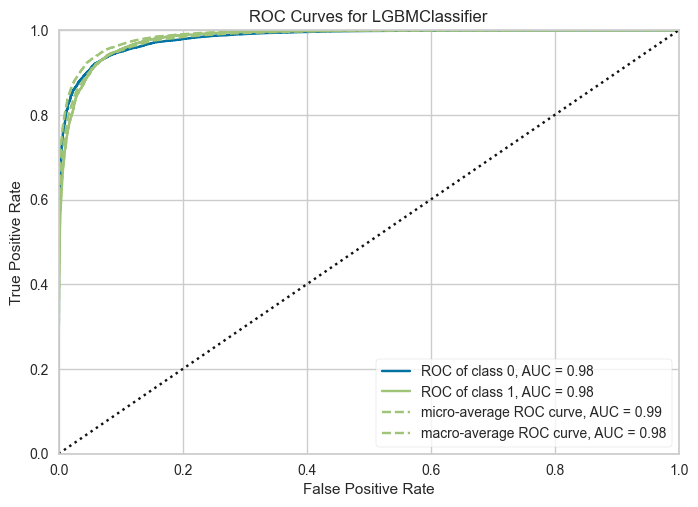

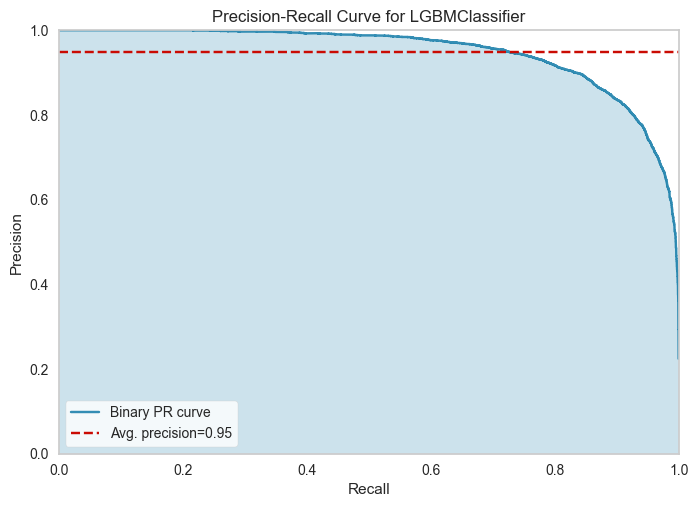

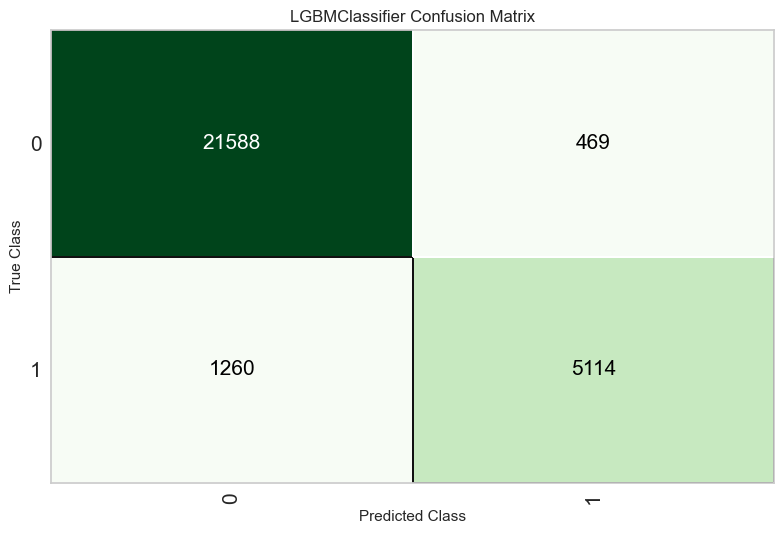

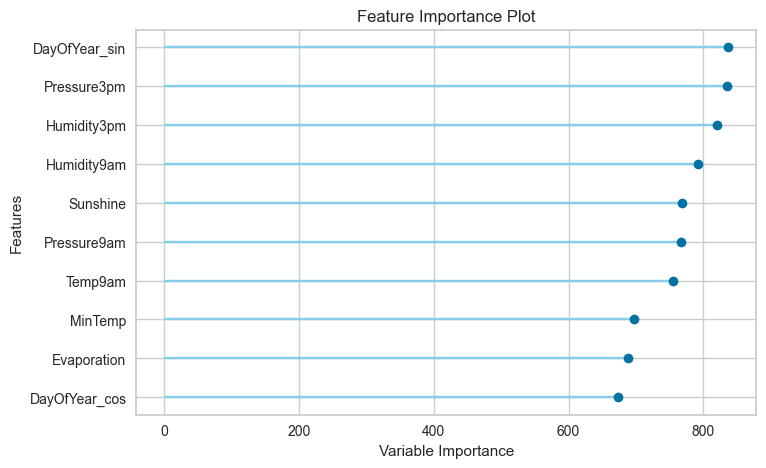

In [123]:
plot_model(final, plot='auc')
plot_model(final, plot='pr')
plot_model(final, plot='confusion_matrix')
plot_model(final, plot='feature') 

El proceso de AutoML con PyCaret permitió comparar múltiples algoritmos de clasificación y seleccionar de manera automática el modelo con mejor rendimiento para la predicción de lluvia. El modelo final seleccionado fue un LGBMClassifier (Light Gradient Boosting Machine), que logró un desempeño sólido tanto en entrenamiento como en el conjunto de prueba.

Según las curvas ROC y Precision–Recall, el modelo alcanzó un AUC de 0.90 y una precisión promedio de 0.77, lo cual indica una buena capacidad para distinguir entre días con y sin lluvia. La matriz de confusión muestra que el modelo acierta correctamente en la mayoría de los casos negativos (sin lluvia), pero también mantiene un nivel de aciertos considerable en la clase positiva (días con lluvia), con 3468 verdaderos positivos frente a 2906 falsos negativos. Esto implica que, si bien aún existen algunas lluvias no detectadas, el modelo logra un equilibrio adecuado entre sensibilidad y precisión.

En cuanto a la importancia de las variables, las más relevantes para la predicción fueron Pressure3pm, WindGustSpeed, Humidity3pm, Humidity9pm, Pressure9pm y Sunshine, lo cual resulta coherente con el comportamiento meteorológico esperado: la presión atmosférica y la humedad son factores determinantes en la formación de lluvias, mientras que la radiación solar y la velocidad del viento también contribuyen significativamente. El dato curioso es que el modelo le aporta gran relevancia al dia del año con la variable DayOfYear_cos.

En síntesis, el enfoque AutoML permitió automatizar la búsqueda y evaluación de modelos, optimizando resultados sin intervención manual extensiva. El modelo final LGBMClassifier se destaca por su rendimiento general, interpretabilidad y equilibrio entre las métricas de evaluación, constituyendo una herramienta robusta para la predicción de lluvia en el conjunto de datos analizado.